## 1. Setup

In [1]:
# Install packages that are not always preinstalled in a fresh Colab runtime.
%pip install -q lightgbm xgboost shap optuna kaleido holidays duckdb


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 5.0 MB/s eta 0:00:00


In [2]:
import os
import gc
import json
import time
import warnings
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import joblib
import duckdb
import holidays
import shap
import optuna

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score, brier_score_loss,
    roc_curve, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score,
)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier, LGBMRegressor

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.facecolor"] = "white"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Setup complete.")


Setup complete.


In [3]:
RF_N_ESTIMATORS = 200          # Random Forest trees (both baseline + per-fold)
XGB_LGBM_N_ESTIMATORS = 300    # boosting rounds for un-tuned baseline runs
OPTUNA_TRIALS_CLASSIFIER = 25  # HPO trials per classifier (XGBoost, LightGBM)
OPTUNA_TRIALS_REGRESSOR = 20   # HPO trials for the LightGBM duration regressor
SHAP_SAMPLE_SIZE = 8000        # rows sampled from the test set for SHAP (full-set
                                # SHAP on millions of rows is computationally
                                # infeasible even on Colab; this is standard practice)
CORR_SAMPLE_SIZE = 2_000_000   # rows sampled for the numeric-feature correlation heatmap --
                                # pandas' .corr() materializes an internal dense float64
                                # matrix regardless of input dtype, so running it on all
                                # 37.9M rows allocates ~3.3GB on top of the already-resident
                                # full df; a multi-million-row sample gives an
                                # indistinguishable Pearson estimate for a fraction of the RAM.
# -----------------------------------------------------------------------------

In [4]:
# ---- Data location ----------------------------------------------------------
# This notebook processes the 72 RAW monthly BTS parquet files directly (bts_2018_01.parquet
# ... bts_2023_12.parquet) rather than a single pre-processed file -- cleaning, joining to
# airport metadata, and feature engineering all happen live in the next few cells.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    # EDIT THIS if you uploaded the 72 files to a different Drive folder.
    RAW_DATA_DIR = Path("/content/drive/MyDrive/PRT661/bts_parquet")
    OUTPUT_DIR = Path("/content/PRT661_outputs")
else:
    # Local/non-Colab fallback -- override via env var for testing.
    RAW_DATA_DIR = Path(os.environ.get("PRT661_RAW_DATA_DIR", "./bts_parquet"))
    OUTPUT_DIR = Path(os.environ.get("PRT661_OUTPUT_DIR", "./PRT661_outputs"))

FIGURES_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = OUTPUT_DIR / "models"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

existing_raw = sorted(RAW_DATA_DIR.glob("bts_*.parquet"))
print(f"Found {len(existing_raw)} raw monthly parquet file(s) in {RAW_DATA_DIR}")

# rather upload directly this session), offer the browser upload widget instead.
if IN_COLAB and len(existing_raw) == 0:
    from google.colab import files
    print(f"No bts_*.parquet files found at {RAW_DATA_DIR} -- either fix the path above and "
          f"re-run this cell, or select all 72 monthly files to upload directly now "
          f"(bts_2018_01.parquet ... bts_2023_12.parquet):")
    RAW_DATA_DIR = Path("/content")
    uploaded = files.upload()
    existing_raw = sorted(RAW_DATA_DIR.glob("bts_*.parquet"))

if len(existing_raw) < 72:
    print(f"WARNING: expected 72 monthly files (Jan 2018-Dec 2023), found {len(existing_raw)}. "
          f"Missing months will simply be absent from the analysis below.")

print(f"IN_COLAB = {IN_COLAB}")
print(f"RAW_DATA_DIR = {RAW_DATA_DIR}")
print(f"{len(existing_raw)} raw monthly file(s) ready for processing")
print(f"Outputs will be saved under: {OUTPUT_DIR.resolve()}")


Mounted at /content/drive
Found 72 raw monthly parquet file(s) in /content/drive/MyDrive/PRT661/bts_parquet
IN_COLAB = True
RAW_DATA_DIR = /content/drive/MyDrive/PRT661/bts_parquet
72 raw monthly file(s) ready for processing
Outputs will be saved under: /content/PRT661_outputs


## 1.3 Checkpointing & resume



In [5]:

FORCE_RECOMPUTE = False
CHECKPOINT_MODELS = True

if IN_COLAB:
    CKPT_DIR = Path("/content/drive/MyDrive/PRT661/checkpoints")
else:
    CKPT_DIR = Path(os.environ.get("PRT661_CKPT_DIR", str(OUTPUT_DIR / "checkpoints")))
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# Big artefacts that must also outlive a runtime recycle live next to the
# checkpoints rather than under the ephemeral /content OUTPUT_DIR.
FEATURES_PATH  = CKPT_DIR / "flights_features.parquet"   # DuckDB-engineered table
DF_CKPT        = CKPT_DIR / "df_engineered.parquet"      # ready-to-model dataframe
OPTUNA_DB      = CKPT_DIR / "optuna_studies.db"
OPTUNA_STORAGE = f"sqlite:///{OPTUNA_DB.as_posix()}"     # per-trial Optuna resume


def _ckpt_file(name):
    return CKPT_DIR / f"{name}.pkl"


def ckpt_exists(name):
    return (not FORCE_RECOMPUTE) and _ckpt_file(name).exists()


def ckpt_save(name, obj, compress=3):
    """Atomic write: temp file + rename, so an interrupted save never leaves a
    half-written checkpoint that a later run would load as if it were complete."""
    tmp = _ckpt_file(name).with_suffix(".pkl.part")
    joblib.dump(obj, tmp, compress=compress)
    tmp.replace(_ckpt_file(name))
    print(f"  [checkpoint saved]    {name}")
    return obj


def ckpt_load(name):
    print(f"  [checkpoint restored] {name}  (skipping recompute)")
    return joblib.load(_ckpt_file(name))


def ckpt_step(name, compute_fn, compress=3):
    """Return checkpoint `name` if present, else run compute_fn(), save, return."""
    if ckpt_exists(name):
        return ckpt_load(name)
    return ckpt_save(name, compute_fn(), compress=compress)


def df_checkpoint_exists():
    return (not FORCE_RECOMPUTE) and DF_CKPT.exists()


# ---- Resume manifest ------------------------------------------------------
print(f"Checkpoint dir: {CKPT_DIR}")
if FORCE_RECOMPUTE:
    print("FORCE_RECOMPUTE = True  ->  every step recomputes; existing checkpoints ignored.")
else:
    _found = []
    if FEATURES_PATH.exists(): _found.append("engineered feature table (flights_features.parquet)")
    if DF_CKPT.exists():       _found.append("ready-to-model dataframe (df_engineered.parquet)")
    if OPTUNA_DB.exists():     _found.append("Optuna study database (optuna_studies.db)")
    _found += [p.stem for p in sorted(CKPT_DIR.glob("*.pkl"))]
    if _found:
        print("Existing checkpoints found -- these will be restored, not recomputed:")
        for _f in _found:
            print(f"  - {_f}")
    else:
        print("No checkpoints yet -- fresh run; every step will compute and save one.")


Checkpoint dir: /content/drive/MyDrive/PRT661/checkpoints
No checkpoints yet -- fresh run; every step will compute and save one.


In [6]:

LOCAL_RAW_DATA_DIR = Path("/content/bts_parquet")

needs_staging = IN_COLAB and str(RAW_DATA_DIR).startswith("/content/drive")

# Skip the multi-GB raw-file copy entirely when an engineered checkpoint
# already exists -- the raw files are only needed to (re)build it.
if needs_staging and (df_checkpoint_exists() or FEATURES_PATH.exists()):
    needs_staging = False
    print("Engineered-data checkpoint present -- skipping raw-file staging.")

if needs_staging:
    import shutil
    LOCAL_RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)

    to_copy = []
    for src in existing_raw:
        dst = LOCAL_RAW_DATA_DIR / src.name
        src_size = src.stat().st_size
        if dst.exists() and dst.stat().st_size == src_size:
            continue
        to_copy.append((src, dst, src_size))

    total_bytes = sum(s for _, _, s in to_copy)
    already_done = len(existing_raw) - len(to_copy)
    print(f"Staging raw files to local disk: {len(to_copy)} to copy "
          f"({total_bytes/1e9:.2f} GB), {already_done} already present and up to date.")

    copied_bytes = 0
    t0 = time.time()
    for i, (src, dst, src_size) in enumerate(to_copy, 1):
        tmp_dst = dst.with_name(dst.name + ".part")
        shutil.copy2(src, tmp_dst)
        copied_size = tmp_dst.stat().st_size
        if copied_size != src_size:
            tmp_dst.unlink(missing_ok=True)
            raise IOError(
                f"Copy size mismatch for {src.name}: source {src_size:,} bytes, "
                f"copied {copied_size:,} bytes. The Drive read may have been interrupted -- "
                f"just re-run this cell (already-good files are skipped automatically)."
            )
        tmp_dst.rename(dst)
        copied_bytes += src_size
        elapsed = time.time() - t0
        rate_mbs = copied_bytes / elapsed / 1e6 if elapsed > 0 else 0
        eta_s = (total_bytes - copied_bytes) / (rate_mbs * 1e6) if rate_mbs > 0 else 0
        print(f"\r  [{i}/{len(to_copy)}] {src.name}  "
              f"{copied_bytes/1e9:.2f}/{total_bytes/1e9:.2f} GB  "
              f"{rate_mbs:.0f} MB/s  ETA {eta_s:.0f}s   ", end="", flush=True)
    if to_copy:
        print(f"\nCopied {len(to_copy)} file(s), {copied_bytes/1e9:.2f} GB, "
              f"in {time.time()-t0:.0f}s.")

    RAW_DATA_DIR = LOCAL_RAW_DATA_DIR
    existing_raw = sorted(RAW_DATA_DIR.glob("bts_*.parquet"))
else:
    print(f"Files already local at {RAW_DATA_DIR} -- no staging copy needed.")

print(f"RAW_DATA_DIR now points to local disk: {RAW_DATA_DIR}")


Staging raw files to local disk: 72 to copy (1.30 GB), 0 already present and up to date.
  [72/72] bts_2023_12.parquet  1.30/1.30 GB  12 MB/s  ETA 0s   
Copied 72 file(s), 1.30 GB, in 104s.
RAW_DATA_DIR now points to local disk: /content/bts_parquet


In [7]:
def save_fig(fig, name, tight=True):
    """Save a matplotlib figure to FIGURES_DIR as PNG (300dpi) and close it."""
    if tight:
        fig.tight_layout()
    path = FIGURES_DIR / f"{name}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"[saved] {path.name}")
    plt.show()
    plt.close(fig)


def save_plotly(fig, name):
    """Save a Plotly figure as both an interactive HTML and a static PNG."""
    html_path = FIGURES_DIR / f"{name}.html"
    fig.write_html(str(html_path))
    try:
        png_path = FIGURES_DIR / f"{name}.png"
        fig.write_image(str(png_path), scale=2)
        print(f"[saved] {html_path.name}, {png_path.name}")
    except Exception as exc:
        print(f"[saved] {html_path.name} (static PNG export skipped: {exc})")
    fig.show()


## 2. Load & Process Data




In [8]:

def _build_feature_table():
    # Download OpenFlights airport metadata (small, public, no auth needed).
    AIRPORTS_PATH = OUTPUT_DIR.parent / "airports.dat"
    AIRPORTS_URL = "https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat"

    if not AIRPORTS_PATH.exists():
        import urllib.request
        urllib.request.urlretrieve(AIRPORTS_URL, AIRPORTS_PATH)
    print(f"OpenFlights airport metadata: {AIRPORTS_PATH} ({AIRPORTS_PATH.stat().st_size/1e3:.0f} KB)")

    AIRPORT_COLUMNS = [
        "airport_id", "name", "city", "country", "iata", "icao",
        "latitude", "longitude", "altitude", "timezone", "dst",
        "tz_database_timezone", "type", "source",
    ]

    def _detect_total_ram_gb():
        """Read total system RAM from /proc/meminfo (Colab and most Linux runtimes).
        Falls back to a conservative 12GB assumption (Colab free-tier default) if
        that file isn't available, e.g. on some non-Linux local setups."""
        try:
            with open("/proc/meminfo") as f:
                for line in f:
                    if line.startswith("MemTotal:"):
                        kb = int(line.split()[1])
                        return kb / 1e6
        except Exception:
            pass
        return 12.0

    t0 = time.time()
    total_ram_gb = _detect_total_ram_gb()

    duckdb_mem_limit_gb = max(2, int(total_ram_gb * 0.7))
    print(f"Detected ~{total_ram_gb:.1f} GB total RAM -- capping DuckDB at {duckdb_mem_limit_gb} GB")

    con = duckdb.connect()
    con.execute(f"PRAGMA memory_limit='{duckdb_mem_limit_gb}GB'")
    con.execute("PRAGMA threads=2")
    con.execute("PRAGMA preserve_insertion_order=false")
    duckdb_tmp_dir = OUTPUT_DIR.parent / ".duckdb_tmp"
    duckdb_tmp_dir.mkdir(parents=True, exist_ok=True)
    con.execute(f"PRAGMA temp_directory='{duckdb_tmp_dir.as_posix()}'")

    con.execute(f"""
        CREATE VIEW airports AS
        SELECT * FROM read_csv_auto('{AIRPORTS_PATH.as_posix()}', header=false, names={AIRPORT_COLUMNS})
    """)
    con.execute("""
        CREATE TABLE airports_clean AS
        SELECT DISTINCT ON (iata) iata, latitude, longitude, city, country
        FROM airports
        WHERE iata IS NOT NULL AND iata != '\\N' AND iata != ''
    """)

    raw_glob = str(RAW_DATA_DIR / "bts_*.parquet")
    con.execute(f"""
        CREATE VIEW flights_raw AS
        SELECT * FROM read_parquet('{raw_glob}', union_by_name=true)
    """)
    n_raw = con.execute("SELECT COUNT(*) FROM flights_raw").fetchone()[0]
    print(f"[load] {n_raw:,} raw flight records from {len(existing_raw)} monthly files")


    con.execute("""
        CREATE TABLE flights_base AS
        SELECT
            f.flight_date, f.carrier, f.origin, f.destination,
            f.crs_dep_time, f.distance, f.arr_del15, f.arr_delay_minutes,
            o.latitude  AS origin_lat, o.longitude AS origin_lon,
            d.latitude  AS dest_lat,   d.longitude AS dest_lon,
            LEAST(GREATEST(f.crs_dep_time // 100, 0), 23) AS crs_dep_hour,
            (isodow(f.flight_date) - 1) AS day_of_week,
            CASE WHEN (isodow(f.flight_date) - 1) IN (5, 6) THEN 1 ELSE 0 END AS is_weekend,
            month(f.flight_date) AS month,
            year(f.flight_date) AS year
        FROM (
            SELECT DISTINCT ON (FlightDate, Reporting_Airline, Flight_Number_Reporting_Airline, Origin, Dest)
                CAST(FlightDate AS DATE)                AS flight_date,
                Reporting_Airline                        AS carrier,
                Origin                                   AS origin,
                Dest                                      AS destination,
                CAST(CRSDepTime AS INTEGER)              AS crs_dep_time,
                CAST(Distance AS DOUBLE)                 AS distance,
                CAST(COALESCE(ArrDel15, 0) AS INTEGER)   AS arr_del15,
                CAST(COALESCE(ArrDelayMinutes, 0) AS DOUBLE) AS arr_delay_minutes
            FROM flights_raw
            WHERE Cancelled = 0 AND Diverted = 0
              AND FlightDate IS NOT NULL AND Origin IS NOT NULL AND Dest IS NOT NULL
        ) f
        LEFT JOIN airports_clean o ON f.origin = o.iata
        LEFT JOIN airports_clean d ON f.destination = d.iata
    """)
    n_base = con.execute("SELECT COUNT(*) FROM flights_base").fetchone()[0]
    print(f"[clean+join] {n_base:,} records")

    # 7-day rolling delay rate per carrier and per origin airport, using only
    # PRIOR days (the window frame excludes the current row) so the current
    # day's outcome never leaks into its own feature -- same guarantee the old
    # pandas .shift(1).rolling(7, min_periods=1) gave, reproduced here as
    # ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING over a per-key/per-day aggregate.
    # The fallback value for a key's very first day (no prior data -- window
    # returns NULL) must be the *unweighted* mean of the per-day aggregated
    # rates (equal weight per carrier-day/origin-day), matching what the old
    # pandas fillna(daily["daily_rate"].mean()) computed -- NOT the per-flight
    # mean, which is weighted by flight volume and gives a measurably different
    # (if tiny-impact, first-day-only) number.
    for key in ["carrier", "origin"]:
        con.execute(f"""
            CREATE TABLE {key}_daily AS
            SELECT {key}, flight_date AS day, AVG(arr_del15) AS daily_rate
            FROM flights_base GROUP BY {key}, flight_date
        """)
        con.execute(f"""
            CREATE TABLE {key}_daily_rate AS
            SELECT {key}, day,
                AVG(daily_rate) OVER (
                    PARTITION BY {key} ORDER BY day
                    ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
                ) AS {key}_delay_rate_7d
            FROM {key}_daily
        """)
    overall_carrier_rate = con.execute("SELECT AVG(daily_rate) FROM carrier_daily").fetchone()[0]
    overall_origin_rate = con.execute("SELECT AVG(daily_rate) FROM origin_daily").fetchone()[0]

    # NOTE: write to the module-level FEATURES_PATH (Drive, survives a
    # runtime recycle); do NOT rebind it to a local /content path here.
    con.execute(f"""
        COPY (
            SELECT b.*,
                COALESCE(cr.carrier_delay_rate_7d, {overall_carrier_rate}) AS carrier_delay_rate_7d,
                COALESCE(orr.origin_delay_rate_7d, {overall_origin_rate}) AS origin_delay_rate_7d
            FROM flights_base b
            LEFT JOIN carrier_daily_rate cr ON b.carrier = cr.carrier AND b.flight_date = cr.day
            LEFT JOIN origin_daily_rate orr ON b.origin = orr.origin AND b.flight_date = orr.day
            WHERE b.distance IS NOT NULL AND b.origin_lat IS NOT NULL AND b.dest_lat IS NOT NULL
            ORDER BY b.flight_date
        ) TO '{FEATURES_PATH.as_posix()}' (FORMAT PARQUET)
    """)
    n_features = con.execute(f"SELECT COUNT(*) FROM read_parquet('{FEATURES_PATH.as_posix()}')").fetchone()[0]
    con.close()
    import shutil as _shutil
    _shutil.rmtree(duckdb_tmp_dir, ignore_errors=True)
    print(f"[features] {n_features:,} fully-engineered records -> {FEATURES_PATH.name} ({time.time()-t0:.0f}s)")

if df_checkpoint_exists():
    print("Ready-to-model df checkpoint present -- skipping DuckDB feature engineering.")
elif FEATURES_PATH.exists():
    print(f"Reusing engineered table {FEATURES_PATH.name} "
          f"({FEATURES_PATH.stat().st_size / 1e6:.0f} MB) -- skipping DuckDB pipeline.")
else:
    _build_feature_table()


OpenFlights airport metadata: /content/airports.dat (1127 KB)
Detected ~53.5 GB total RAM -- capping DuckDB at 37 GB
[load] 38,889,007 raw flight records from 72 monthly files


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[clean+join] 37,893,257 records


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[features] 37,877,189 fully-engineered records -> flights_features.parquet (50s)


In [9]:
t0 = time.time()

if df_checkpoint_exists():
    df = pd.read_parquet(DF_CKPT)
    print(f"Restored ready-to-model dataframe from checkpoint: {len(df):,} rows x "
          f"{df.shape[1]} cols in {time.time() - t0:.1f}s "
          f"({df.memory_usage(deep=True).sum() / 1e9:.2f} GB)")
else:


    import pyarrow.parquet as pq
    import pyarrow as pa

    table = pq.read_table(FEATURES_PATH)
    for col_name in ["carrier", "origin", "destination"]:
        idx = table.schema.get_field_index(col_name)
        table = table.set_column(idx, col_name, table.column(col_name).dictionary_encode())
    for col_name in ["distance", "origin_lat", "origin_lon", "dest_lat", "dest_lon",
                      "arr_delay_minutes", "carrier_delay_rate_7d", "origin_delay_rate_7d"]:
        idx = table.schema.get_field_index(col_name)
        table = table.set_column(idx, col_name, table.column(col_name).cast(pa.float32()))
    for col_name, dtype in [("crs_dep_time", pa.int16()), ("crs_dep_hour", pa.int8()),
                             ("day_of_week", pa.int8()), ("is_weekend", pa.int8()),
                             ("month", pa.int8()), ("year", pa.int16()), ("arr_del15", pa.int8())]:
        idx = table.schema.get_field_index(col_name)
        table = table.set_column(idx, col_name, table.column(col_name).cast(dtype))


    df = table.to_pandas(date_as_object=False, split_blocks=True, self_destruct=True)
    del table
    gc.collect()


    us_holidays = holidays.UnitedStates(years=df["flight_date"].dt.year.unique().tolist())
    holiday_dates = pd.to_datetime(list(us_holidays.keys()))
    df["is_holiday"] = df["flight_date"].dt.normalize().isin(holiday_dates).astype("int8")

    print(f"Loaded + engineered {len(df):,} rows x {df.shape[1]} columns in {time.time()-t0:.1f}s")
    print(f"Memory footprint: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
    df.head()
print(f"df ready: {len(df):,} rows, {df.shape[1]} columns, {df.memory_usage(deep=True).sum() / 1e9:.2f} GB in memory")


Loaded + engineered 37,877,189 rows x 20 columns in 9.6s
Memory footprint: 2.08 GB
df ready: 37,877,189 rows, 20 columns, 2.08 GB in memory


## 3. Five Vs Analysis (measured, not estimated)

Assessment 1 estimated these figures ahead of time; here they are recomputed directly
from the loaded dataset.


In [10]:
five_vs = {
    "Volume": f"{len(df):,} flight records, {df.memory_usage(deep=True).sum()/1e9:.2f} GB in memory "
              f"({sum(p.stat().st_size for p in existing_raw)/1e9:.2f} GB raw Parquet input "
              f"across {len(existing_raw)} monthly files)",
    "Velocity": f"Batch monthly ingestion, {df['flight_date'].min().date()} to {df['flight_date'].max().date()} "
                f"({df['year'].nunique()} years, {df.groupby(['year', df['flight_date'].dt.month]).ngroups} months)",
    "Variety": f"{df['carrier'].nunique()} carriers, {df['origin'].nunique()} origin airports, "
               f"{df['destination'].nunique()} destination airports",
    "Veracity": f"{df.isna().sum().sum()} missing values after upstream cleaning "
                f"(dedup on flight-leg key, cancelled/diverted flights dropped)",
    "Value": f"Overall delay rate (15+ min): {df['arr_del15'].mean()*100:.1f}% -- "
             f"supports delay classification, duration regression, carrier/airport benchmarking",
}
for k, v in five_vs.items():
    print(f"{k:10s}: {v}")

pd.DataFrame(five_vs.items(), columns=["Dimension", "Measured value"]).to_csv(
    OUTPUT_DIR / "five_vs_summary.csv", index=False
)


Volume    : 37,877,189 flight records, 2.08 GB in memory (1.30 GB raw Parquet input across 72 monthly files)
Velocity  : Batch monthly ingestion, 2018-01-01 to 2023-12-31 (6 years, 72 months)
Variety   : 19 carriers, 379 origin airports, 379 destination airports
Veracity  : 0 missing values after upstream cleaning (dedup on flight-leg key, cancelled/diverted flights dropped)
Value     : Overall delay rate (15+ min): 18.3% -- supports delay classification, duration regression, carrier/airport benchmarking


## 4. Graph-Derived Hub Features




In [11]:
if {"origin_degree_centrality", "origin_hub_tier"}.issubset(df.columns):
    print("Graph-derived hub features already present (restored from checkpoint).")
else:
    # Out-degree: distinct destinations reachable from each origin airport.
    degree = df.groupby("origin", observed=True)["destination"].nunique()
    degree_norm = (degree - degree.min()) / (degree.max() - degree.min())
    df["origin_degree_centrality"] = df["origin"].map(degree_norm).astype("float32")

    # Hub tier: by total flight volume out of each origin airport.
    volume = df["origin"].value_counts()
    top_decile = volume.quantile(0.90)
    top_4deciles = volume.quantile(0.60)

    def tier_for(v):
        if v >= top_decile:
            return "major"
        elif v >= top_4deciles:
            return "medium"
        return "small"

    hub_tier_map = volume.apply(tier_for)
    df["origin_hub_tier"] = df["origin"].map(hub_tier_map).astype("category")

    print(df[["origin", "origin_degree_centrality", "origin_hub_tier"]].drop_duplicates("origin").shape[0], "airports classified")
    print(df["origin_hub_tier"].value_counts())
    df[["origin", "origin_degree_centrality", "origin_hub_tier"]].drop_duplicates("origin").sort_values(
        "origin_degree_centrality", ascending=False
    ).head(10)


# ---- Persist the fully-engineered dataframe --------------------------------
# DuckDB feature engineering + holiday flag + these graph features together
# are the deterministic, expensive 'assemble the dataset' stage. Save it once
# so any later 'Run all' reloads it in seconds instead of rebuilding from the
# 72 raw monthly files.
if not df_checkpoint_exists():
    try:
        _t = time.time()
        df.to_parquet(DF_CKPT, compression="zstd", index=False)
        print(f"  [checkpoint saved]    {DF_CKPT.name} "
              f"({DF_CKPT.stat().st_size / 1e6:.0f} MB, {time.time() - _t:.0f}s)")
    except Exception as _exc:
        print(f"  WARNING: could not write {DF_CKPT.name} ({_exc}). Continuing without "
              f"dataframe-level resume; the feature-table + per-model checkpoints still apply.")


379 airports classified
origin_hub_tier
major     26937691
medium     9311492
small      1628006
Name: count, dtype: int64
  [checkpoint saved]    df_engineered.parquet (454 MB, 18s)


## 5. Exploratory Data Analysis (Advanced Visualisations)

Every figure in this section is saved to `figures/` as it's produced.


### 5.1 Overall delay rate and class balance

[saved] 01_class_balance.png


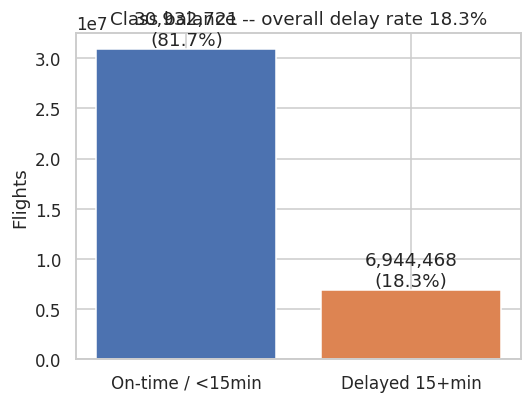

In [12]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["arr_del15"].value_counts().sort_index()
labels = ["On-time / <15min", "Delayed 15+min"]
colors = ["#4C72B0", "#DD8452"]
ax.bar(labels, counts.values, color=colors)
for i, v in enumerate(counts.values):
    ax.text(i, v + len(df)*0.01, f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center")
ax.set_ylabel("Flights")
ax.set_title(f"Class balance -- overall delay rate {df['arr_del15'].mean()*100:.1f}%")
save_fig(fig, "01_class_balance")


### 5.2 Monthly delay rate trend, 2018-2023 (COVID period highlighted)

[saved] 02_monthly_delay_trend.png


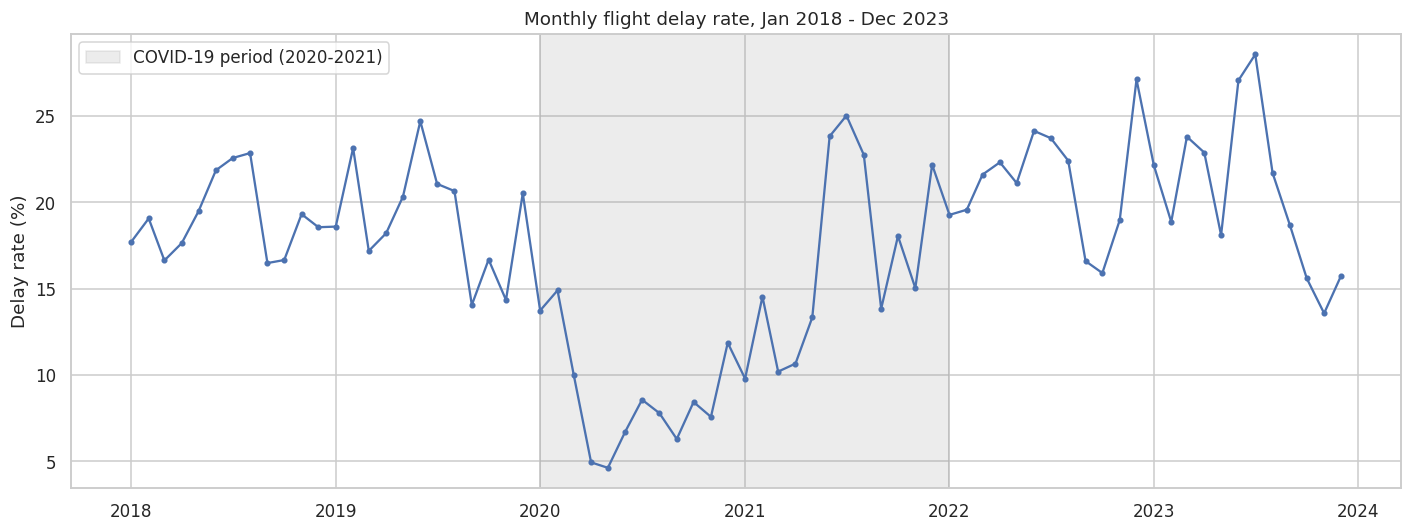

In [13]:
monthly = df.groupby(df["flight_date"].dt.to_period("M"))["arr_del15"].mean() * 100
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly.index, monthly.values, marker="o", markersize=3, color="#4C72B0")
ax.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2021-12-31"), color="grey", alpha=0.15,
           label="COVID-19 period (2020-2021)")
ax.set_ylabel("Delay rate (%)")
ax.set_title("Monthly flight delay rate, Jan 2018 - Dec 2023")
ax.legend()
save_fig(fig, "02_monthly_delay_trend")


### 5.3 Delay rate by hour-of-day x day-of-week (heatmap)

[saved] 03_hour_dow_heatmap.png


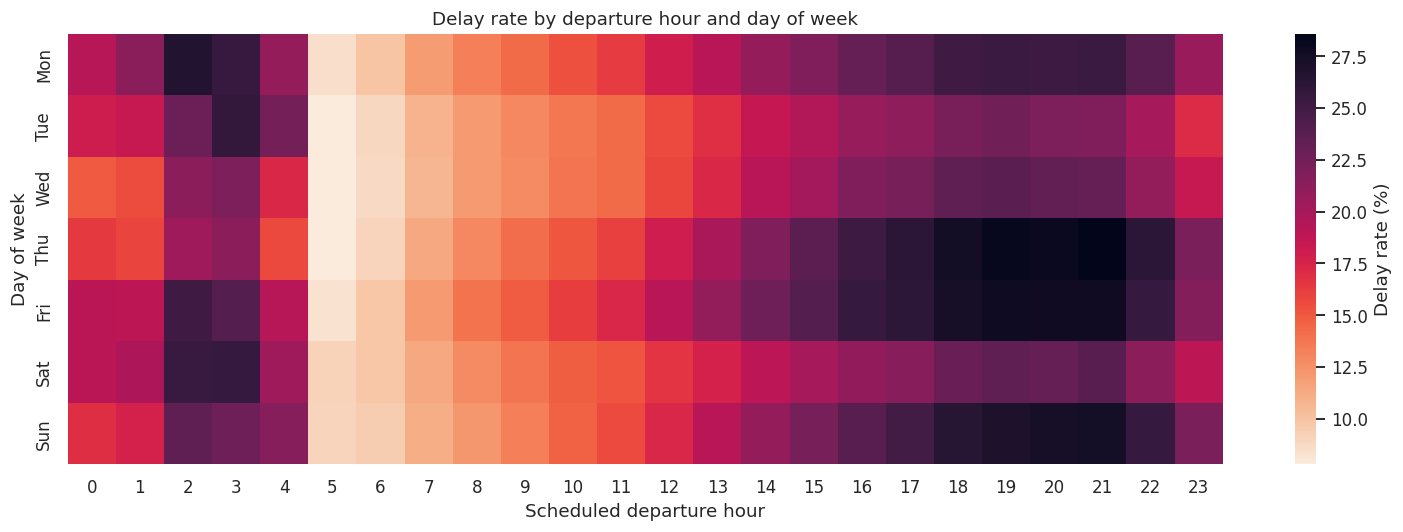

In [14]:
pivot = df.pivot_table(index="day_of_week", columns="crs_dep_hour", values="arr_del15", aggfunc="mean") * 100
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, cmap="rocket_r", ax=ax, cbar_kws={"label": "Delay rate (%)"},
            yticklabels=day_labels)
ax.set_xlabel("Scheduled departure hour")
ax.set_ylabel("Day of week")
ax.set_title("Delay rate by departure hour and day of week")
save_fig(fig, "03_hour_dow_heatmap")


### 5.4 Delay rate by carrier

[saved] 04_delay_rate_by_carrier.png


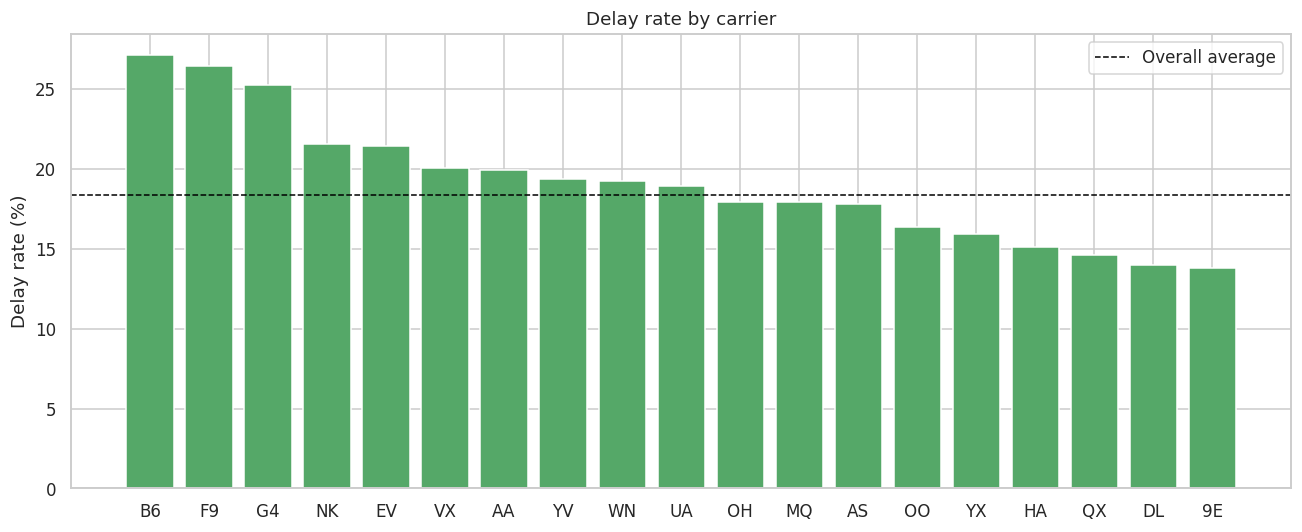

In [15]:
carrier_rate = (df.groupby("carrier", observed=True)["arr_del15"].mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(carrier_rate.index.astype(str), carrier_rate.values, color="#55A868")
ax.axhline(df["arr_del15"].mean()*100, color="black", linestyle="--", linewidth=1, label="Overall average")
ax.set_ylabel("Delay rate (%)")
ax.set_title("Delay rate by carrier")
ax.legend()
save_fig(fig, "04_delay_rate_by_carrier")


### 5.5 Top 15 origin airports by volume, coloured by delay rate

[saved] 05_top_airports_volume_delay.png


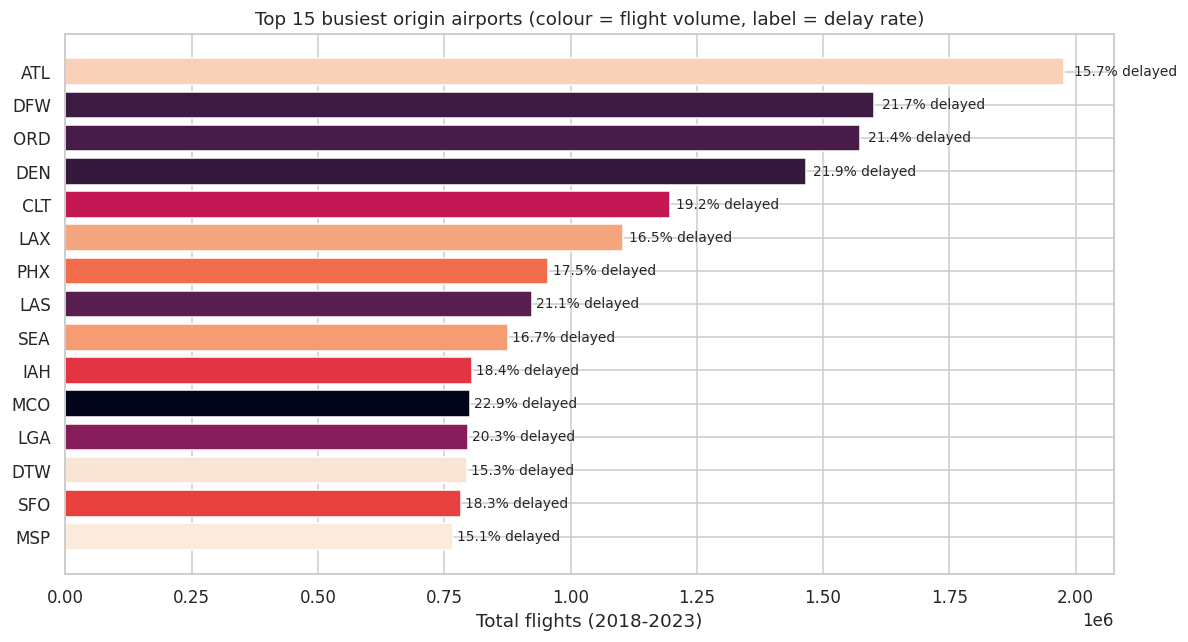

In [16]:
airport_stats = df.groupby("origin", observed=True).agg(
    flights=("arr_del15", "size"), delay_rate=("arr_del15", "mean")
).sort_values("flights", ascending=False).head(15)
airport_stats["delay_rate"] *= 100

fig, ax = plt.subplots(figsize=(11, 6))
norm = plt.Normalize(airport_stats["delay_rate"].min(), airport_stats["delay_rate"].max())
colors = plt.get_cmap("rocket_r")(norm(airport_stats["delay_rate"]))
bars = ax.barh(airport_stats.index[::-1], airport_stats["flights"][::-1], color=colors[::-1])
for bar, rate in zip(bars, airport_stats["delay_rate"][::-1]):
    ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2, f"{rate:.1f}% delayed",
            va="center", fontsize=9)
ax.set_xlabel("Total flights (2018-2023)")
ax.set_title("Top 15 busiest origin airports (colour = flight volume, label = delay rate)")
save_fig(fig, "05_top_airports_volume_delay")


### 5.6 Delay-minute distribution by carrier (delayed flights only, log scale)

[saved] 06_delay_duration_violin_by_carrier.png


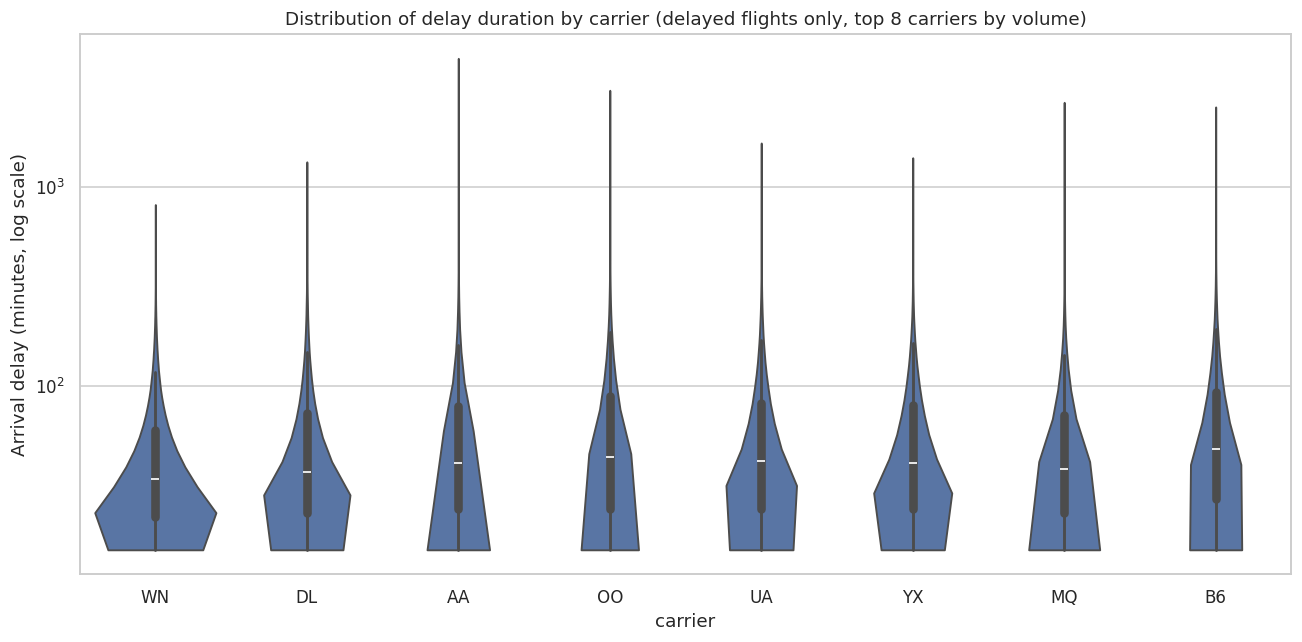

In [17]:
delayed_only = df[df["arr_del15"] == 1]
top8_carriers = df["carrier"].value_counts().head(8).index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(
    data=delayed_only[delayed_only["carrier"].isin(top8_carriers)],
    x="carrier", y="arr_delay_minutes", ax=ax, cut=0, order=top8_carriers,
)
ax.set_yscale("log")
ax.set_ylabel("Arrival delay (minutes, log scale)")
ax.set_title("Distribution of delay duration by carrier (delayed flights only, top 8 carriers by volume)")
save_fig(fig, "06_delay_duration_violin_by_carrier")


### 5.7 Distance vs. delay minutes (hexbin density -- 37M points can't be scatter-plotted directly)

[saved] 07_distance_vs_delay_hexbin.png


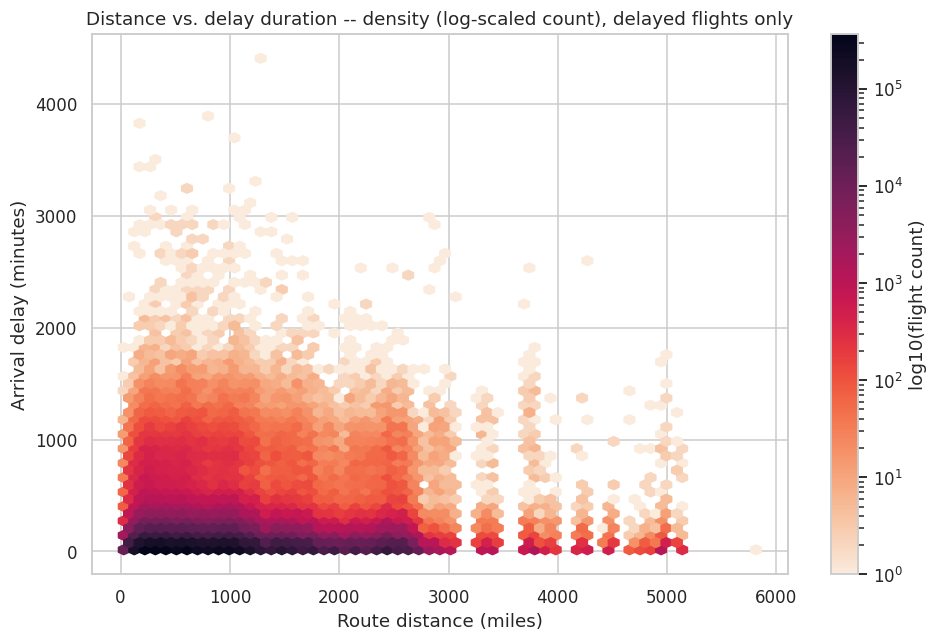

21294

In [18]:
fig, ax = plt.subplots(figsize=(9, 6))
hb = ax.hexbin(delayed_only["distance"], delayed_only["arr_delay_minutes"],
                gridsize=60, cmap="rocket_r", mincnt=1, bins="log")
ax.set_xlabel("Route distance (miles)")
ax.set_ylabel("Arrival delay (minutes)")
ax.set_title("Distance vs. delay duration -- density (log-scaled count), delayed flights only")
fig.colorbar(hb, ax=ax, label="log10(flight count)")
save_fig(fig, "07_distance_vs_delay_hexbin")

# delayed_only (a ~15-20% full-row copy of df, made back in 5.6) isn't used
# again anywhere below -- freeing it here instead of leaving it resident for
# the rest of the notebook.
del delayed_only
gc.collect()

### 5.8 Correlation heatmap of engineered numeric features

[saved] 08_correlation_heatmap.png


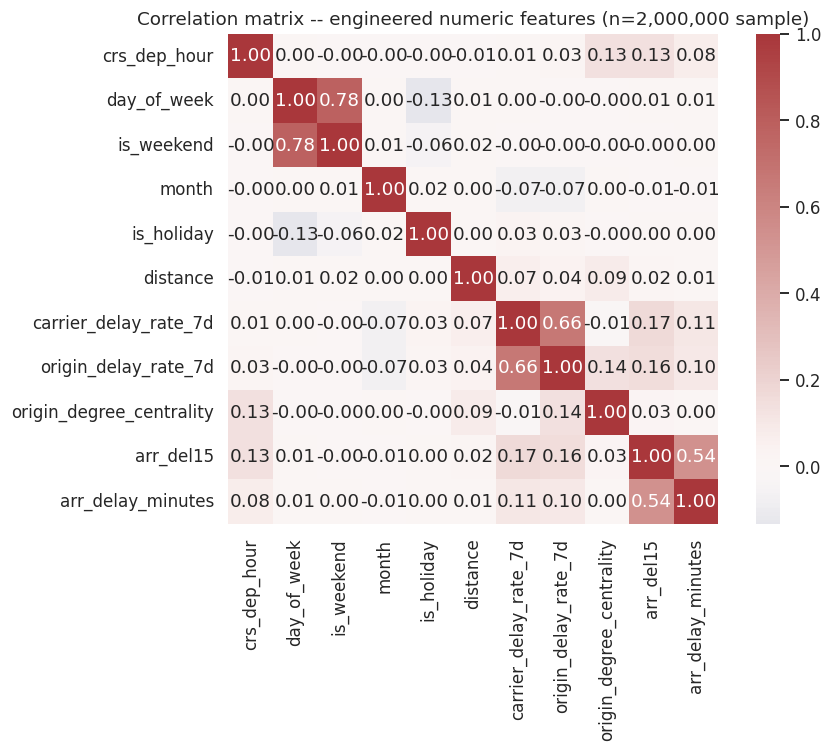

In [19]:
numeric_feats = ["crs_dep_hour", "day_of_week", "is_weekend", "month", "is_holiday",
                  "distance", "carrier_delay_rate_7d", "origin_delay_rate_7d",
                  "origin_degree_centrality", "arr_del15", "arr_delay_minutes"]

# Sampled rather than run on all 37.9M rows -- see CORR_SAMPLE_SIZE in the Config
# cell for why: pandas' .corr() forces an internal dense float64 matrix no matter
# what dtype the input columns are, which is what actually OOM'd here before.
n_corr_sample = min(CORR_SAMPLE_SIZE, len(df))
corr_sample = df[numeric_feats].sample(n=n_corr_sample, random_state=RANDOM_STATE)
corr = corr_sample.corr()
del corr_sample
gc.collect()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax, square=True)
ax.set_title(f"Correlation matrix -- engineered numeric features (n={n_corr_sample:,} sample)")
save_fig(fig, "08_correlation_heatmap")

### 5.9 Interactive: monthly delay rate for the top 6 carriers (Plotly)

In [20]:
top6 = df["carrier"].value_counts().head(6).index.tolist()
# Aggregate over the FULL df first (cheap -- output is just months x carriers),
# then filter down to top6. Doing it the other way around (filter df to top6
# rows first, THEN group by) makes a full extra copy of most of the 37.9M-row
# dataframe before aggregation even starts, since a handful of major carriers
# account for most flight volume -- that ordering is what actually crashed
# here. 5.10 and 5.11 below already aggregate-then-filter; this just matches.
monthly_carrier_all = (
    df.groupby([df["flight_date"].dt.to_period("M"), "carrier"], observed=True)["arr_del15"]
    .mean().mul(100).rename("delay_rate").reset_index()
)
monthly_carrier = monthly_carrier_all[monthly_carrier_all["carrier"].isin(top6)].copy()
del monthly_carrier_all
monthly_carrier["flight_date"] = monthly_carrier["flight_date"].dt.to_timestamp()

fig = px.line(monthly_carrier, x="flight_date", y="delay_rate", color="carrier",
              title="Monthly delay rate by carrier (top 6 by volume), 2018-2023",
              labels={"delay_rate": "Delay rate (%)", "flight_date": "Month"})
fig.add_vrect(x0="2020-01-01", x1="2021-12-31", fillcolor="grey", opacity=0.15,
              line_width=0, annotation_text="COVID-19 period")
save_plotly(fig, "09_interactive_monthly_delay_by_carrier")

[saved] 09_interactive_monthly_delay_by_carrier.html (static PNG export skipped: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido
)


### 5.10 Interactive: US map of origin airports (Plotly geo scatter)

In [21]:
airport_geo = df.groupby("origin", observed=True).agg(
    flights=("arr_del15", "size"), delay_rate=("arr_del15", "mean"),
    lat=("origin_lat", "first"), lon=("origin_lon", "first"),
).reset_index()
airport_geo["delay_rate"] *= 100
airport_geo = airport_geo[airport_geo["flights"] >= 100]  # drop near-empty airports for a legible map

fig = px.scatter_geo(
    airport_geo, lat="lat", lon="lon", size="flights", color="delay_rate",
    hover_name="origin", scope="usa", color_continuous_scale="RdYlGn_r",
    size_max=35, title="Origin airports: bubble size = flight volume, colour = delay rate (%)",
)
save_plotly(fig, "10_interactive_us_airport_map")


[saved] 10_interactive_us_airport_map.html (static PNG export skipped: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido
)


### 5.11 Interactive: carrier -> hub tier delay contribution (Plotly sunburst)

In [22]:
sun_data = df.groupby(["carrier", "origin_hub_tier"], observed=True).agg(
    flights=("arr_del15", "size"), delay_rate=("arr_del15", "mean")
).reset_index()
sun_data = sun_data[sun_data["carrier"].isin(top8_carriers)].copy()
sun_data["delay_rate"] *= 100

# carrier / origin_hub_tier are category dtype with a fixed list of categories
# baked in (all 19 carriers / all 3 hub tiers), even after filtering rows down
# to top8_carriers. Plotly's px.sunburst does its own internal groupby to
# build the hierarchy, WITHOUT observed=True, so it still enumerates every
# category -- including ones with zero actual rows left in this filtered
# data. That phantom empty group has flights summing to 0, and Plotly's
# weighted color average (np.average(..., weights=0)) divides by that sum ->
# ZeroDivisionError. Casting to plain strings drops the "unused categories"
# baggage so Plotly's groupby only ever sees values that actually exist here.
sun_data["carrier"] = sun_data["carrier"].astype(str)
sun_data["origin_hub_tier"] = sun_data["origin_hub_tier"].astype(str)

fig = px.sunburst(
    sun_data, path=["carrier", "origin_hub_tier"], values="flights", color="delay_rate",
    color_continuous_scale="RdYlGn_r", title="Flight volume by carrier and origin hub tier (colour = delay rate %)",
)
save_plotly(fig, "11_interactive_sunburst_carrier_hub")

[saved] 11_interactive_sunburst_carrier_hub.html (static PNG export skipped: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido
)


## 6. Modelling Setup -- Walk-Forward Cross-Validation




In [23]:
NUMERIC_FEATURES = [
    "crs_dep_hour", "day_of_week", "is_weekend", "month", "is_holiday",
    "distance", "carrier_delay_rate_7d", "origin_delay_rate_7d", "origin_degree_centrality",
]
CATEGORICAL_FEATURES = ["carrier", "origin_hub_tier"]
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = "arr_del15"

WALK_FORWARD_FOLDS = [
    {"name": "Fold 1", "train_years": [2018], "test_year": 2019},
    {"name": "Fold 2", "train_years": [2018, 2019], "test_year": 2022},
    {"name": "Fold 3 (production)", "train_years": [2018, 2019, 2022], "test_year": 2023},
]

def _gpu_available():
    """True if an NVIDIA GPU is visible to this runtime. Used to opt XGBoost
    into GPU training automatically when one is attached (e.g. a Colab T4
    runtime, picked mainly for its bundled higher system RAM rather than for
    the GPU itself), while falling back cleanly to CPU everywhere else --
    this notebook must still run unmodified on a plain CPU runtime."""
    try:
        import subprocess
        subprocess.run(["nvidia-smi"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=True)
        return True
    except Exception:
        return False

# XGBoost's pip wheel ships with CUDA support built in already (no extra
# install needed), so this is a safe, low-risk speed-up when a GPU happens to
# be attached. RandomForest/LogisticRegression have no GPU path in scikit-learn,
# and LightGBM's GPU build needs a non-default install on Colab that's easy to
# get wrong -- neither is touched here, both stay on CPU (n_jobs=-1).
XGB_DEVICE = "cuda" if _gpu_available() else "cpu"
XGB_TREE_METHOD = "hist"  # same tree_method value for both CPU and GPU in xgboost>=2.0; `device` picks the backend
print(f"XGBoost device: {XGB_DEVICE}")

# Pin every numeric model-input column to float32 -- left as the mix of
# int64/float32 columns they were engineered with, sklearn's ColumnTransformer
# would silently upcast the whole transformed matrix to float64 (numpy's type
# promotion rule for mixed int64/float32 concatenation), roughly doubling the
# transformed feature matrix's memory footprint for no accuracy benefit at
# this dataset's scale (tens of millions of rows).
for _col in NUMERIC_FEATURES:
    df[_col] = df[_col].astype("float32")

def make_preprocessor():
    # StandardScaler on the numeric block: harmless for the tree models (RF,
    # XGBoost, LightGBM are invariant to monotonic feature scaling) and
    # necessary for LogisticRegression's "saga" solver (see cell below) to
    # converge well -- saga, unlike lbfgs, is sensitive to unscaled features
    # (e.g. distance ranging 0-3000 vs is_weekend 0/1).
    #
    # sparse_output=False on OneHotEncoder: with 19 carriers + 3 hub tiers (22
    # one-hot columns) against only 9 numeric columns, ColumnTransformer's
    # default sparse_threshold would otherwise emit ONE sparse CSR matrix for
    # everything, including the numeric block (which has no real sparsity to
    # exploit -- StandardScaler output is virtually all nonzero, so storing it
    # as sparse costs more per cell than plain dense float32, not less). Worse:
    # sklearn's RandomForestClassifier.fit() explicitly requires CSC format
    # (`accept_sparse="csc"` in its own validation) and will silently convert a
    # CSR input to CSC internally -- i.e. materialize a SECOND full copy of the
    # transformed training matrix in a different sparse layout, on top of the
    # first, at exactly the point (RF, the largest/most RAM-sensitive model
    # here) least able to afford it. Forcing dense output here makes
    # ColumnTransformer's overall output dense unconditionally, so this
    # conversion never happens for any of the four models.
    return ColumnTransformer(
        [
            ("cat", OneHotEncoder(handle_unknown="ignore", dtype=np.float32, sparse_output=False), CATEGORICAL_FEATURES),
            ("num", StandardScaler(), NUMERIC_FEATURES),
        ],
    )

def get_split(train_years, test_year):
    train = df[df["year"].isin(train_years)]
    test = df[df["year"] == test_year]
    X_train, y_train = train[ALL_FEATURES], train[TARGET]
    X_test, y_test = test[ALL_FEATURES], test[TARGET]
    return X_train, y_train, X_test, y_test

def evaluate_classifier(model, X_test, y_test):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "auc_roc": roc_auc_score(y_test, proba),
        "f1": f1_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred),
        "brier": brier_score_loss(y_test, proba),
    }, proba, pred

print("Walk-forward folds:")
for f in WALK_FORWARD_FOLDS:
    print(f"  {f['name']}: train={f['train_years']} -> test={f['test_year']}")

XGBoost device: cuda
Walk-forward folds:
  Fold 1: train=[2018] -> test=2019
  Fold 2: train=[2018, 2019] -> test=2022
  Fold 3 (production): train=[2018, 2019, 2022] -> test=2023


## 7. Walk-Forward Cross-Validated Training -- Baseline & Advanced Models




In [24]:
def build_model(name):
    if name == "logistic_regression":
        # solver="saga": lbfgs needs the full design matrix resident (upcast to
        # float64) for each quasi-Newton update -- confirmed OOM cause at this
        # dataset's scale. saga is sklearn's recommended solver for data this
        # size and solves the identical L2-regularized problem.
        return Pipeline([("pre", make_preprocessor()),
                          ("model", LogisticRegression(max_iter=1000, class_weight="balanced", solver="saga"))])
    if name == "random_forest":
        return Pipeline([("pre", make_preprocessor()),
                          ("model", RandomForestClassifier(
                              n_estimators=RF_N_ESTIMATORS, max_depth=14,
                              class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE))])
    if name == "xgboost":
        return None  # built per-fold below (needs scale_pos_weight from y_train)
    if name == "lightgbm":
        return Pipeline([("pre", make_preprocessor()),
                          ("model", LGBMClassifier(
                              n_estimators=XGB_LGBM_N_ESTIMATORS, learning_rate=0.08,
                              class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE, verbosity=-1))])
    raise ValueError(name)

# Each (fold, model) fit is checkpointed individually: only its metrics row and
# its (y_test, predicted-proba) arrays are stored -- NOT the fitted pipeline,
# which for RandomForest on tens of millions of rows is huge and is deleted
# right after scoring here anyway. A re-run reloads finished combos and only
# fits the ones still missing.
walk_forward_results = []
fold_predictions = {}

for fold in WALK_FORWARD_FOLDS:
    print(f"\n=== {fold['name']}: train={fold['train_years']} -> test={fold['test_year']} ===")
    fold_predictions[fold["name"]] = {}
    fold_tag = fold["name"].split()[0].lower() + str(fold["test_year"])
    split = None  # materialised lazily, only if a model in this fold needs fitting

    for model_name in ["logistic_regression", "random_forest", "xgboost", "lightgbm"]:
        ck = f"wf_{fold_tag}_{model_name}"
        if ckpt_exists(ck):
            rec = ckpt_load(ck)
        else:
            if split is None:
                split = get_split(fold["train_years"], fold["test_year"])
                print(f"  train={len(split[0]):,} rows, test={len(split[2]):,} rows")
            X_train, y_train, X_test, y_test = split
            t0 = time.time()
            if model_name == "xgboost":
                scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
                model = Pipeline([("pre", make_preprocessor()),
                                   ("model", XGBClassifier(
                                       n_estimators=XGB_LGBM_N_ESTIMATORS, max_depth=6, learning_rate=0.08,
                                       scale_pos_weight=scale_pos_weight, eval_metric="auc",
                                       tree_method=XGB_TREE_METHOD, device=XGB_DEVICE,
                                       n_jobs=-1, random_state=RANDOM_STATE))])
            else:
                model = build_model(model_name)

            model.fit(X_train, y_train)
            metrics, proba, pred = evaluate_classifier(model, X_test, y_test)
            metrics.update({"fold": fold["name"], "model": model_name, "train_rows": len(X_train),
                             "test_rows": len(X_test), "seconds": round(time.time() - t0, 1)})
            rec = {"metrics": metrics,
                    "y_test": np.asarray(y_test.values),
                    "proba": np.asarray(proba)}
            ckpt_save(ck, rec)
            del model, pred
            gc.collect()

        walk_forward_results.append(rec["metrics"])
        fold_predictions[fold["name"]][model_name] = (rec["y_test"], rec["proba"])
        m = rec["metrics"]
        print(f"  [{model_name:20s}] AUC={m['auc_roc']:.4f} F1={m['f1']:.4f} ({m['seconds']:.0f}s)")

walk_forward_df = pd.DataFrame(walk_forward_results)
walk_forward_df.to_csv(OUTPUT_DIR / "walk_forward_results.csv", index=False)
walk_forward_df



=== Fold 1: train=[2018] -> test=2019 ===
  train=7,071,325 rows, test=7,266,528 rows
  [checkpoint saved]    wf_fold2019_logistic_regression
  [logistic_regression ] AUC=0.6368 F1=0.3641 (145s)
  [checkpoint saved]    wf_fold2019_random_forest
  [random_forest       ] AUC=0.6500 F1=0.3706 (592s)
  [checkpoint saved]    wf_fold2019_xgboost
  [xgboost             ] AUC=0.6481 F1=0.3694 (31s)
  [checkpoint saved]    wf_fold2019_lightgbm
  [lightgbm            ] AUC=0.6489 F1=0.3706 (72s)

=== Fold 2: train=[2018, 2019] -> test=2022 ===
  train=14,337,853 rows, test=6,528,008 rows
  [checkpoint saved]    wf_fold2022_logistic_regression
  [logistic_regression ] AUC=0.6518 F1=0.3980 (277s)
  [checkpoint saved]    wf_fold2022_random_forest
  [random_forest       ] AUC=0.6633 F1=0.4044 (1190s)
  [checkpoint saved]    wf_fold2022_xgboost
  [xgboost             ] AUC=0.6648 F1=0.4058 (50s)
  [checkpoint saved]    wf_fold2022_lightgbm
  [lightgbm            ] AUC=0.6657 F1=0.4061 (112s)

=== Fo

,auc_roc,f1,precision,recall,brier,fold,model,train_rows,test_rows,seconds
0,0.636763,0.364102,0.261583,0.598772,0.236135,Fold 1,logistic_regression,7071325,7266528,144.8
1,0.649968,0.370566,0.269857,0.591198,0.227916,Fold 1,random_forest,7071325,7266528,592.2
2,0.648115,0.369435,0.270058,0.584535,0.227729,Fold 1,xgboost,7071325,7266528,31.3
3,0.648867,0.370557,0.270761,0.586855,0.228142,Fold 1,lightgbm,7071325,7266528,72.1
4,0.651800,0.398016,0.284764,0.660834,0.244558,Fold 2,logistic_regression,14337853,6528008,277.3
5,0.663289,0.404431,0.293206,0.651617,0.235228,Fold 2,random_forest,14337853,6528008,1190.2
6,0.664846,0.405780,0.295035,0.649627,0.235033,Fold 2,xgboost,14337853,6528008,49.7
7,0.665743,0.406124,0.294566,0.653689,0.235845,Fold 2,lightgbm,14337853,6528008,111.8
8,0.659378,0.397110,0.288441,0.637155,0.236690,Fold 3 (production),logistic_regression,20865861,6740139,449.8
9,0.672976,0.405155,0.295906,0.642286,0.231686,Fold 3 (production),random_forest,20865861,6740139,1797.5


In [25]:
summary = walk_forward_df.groupby("model")[["auc_roc", "f1", "precision", "recall", "brier"]].agg(["mean", "std"])
print("Walk-forward performance summary (mean +/- std across folds):")
summary


Walk-forward performance summary (mean +/- std across folds):


auc_roc                  f1           precision  \
                         mean       std      mean       std      mean   
model                                                                   
lightgbm             0.662786  0.012701  0.394102  0.020393  0.287145   
logistic_regression  0.649314  0.011510  0.386409  0.019324  0.278263   
random_forest        0.662078  0.011552  0.393384  0.019764  0.286323   
xgboost              0.662276  0.013068  0.393628  0.020952  0.287237   

                                 recall               brier            
                          std      mean       std      mean       std  
model                                                                  
lightgbm             0.014210  0.628085  0.036053  0.232041  0.003852  
logistic_regression  0.014562  0.632254  0.031320  0.239128  0.004711  
random_forest        0.014324  0.628367  0.032526  0.231610  0.003656  
xgboost              0.014899  0.625226  0.035472  0.231441  0.003654

[saved] 12_walk_forward_model_comparison.png


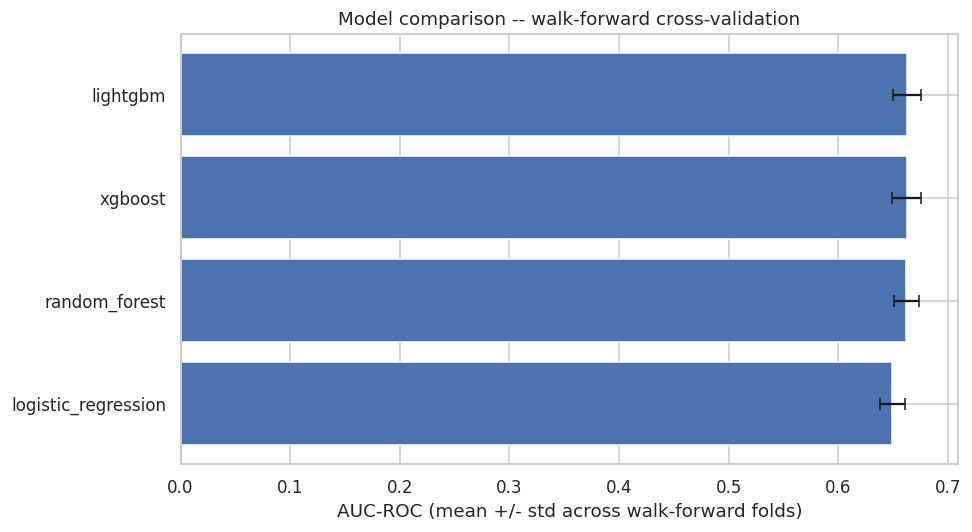

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
means = walk_forward_df.groupby("model")["auc_roc"].mean().sort_values()
stds = walk_forward_df.groupby("model")["auc_roc"].std().reindex(means.index)
ax.barh(means.index, means.values, xerr=stds.values, color="#4C72B0", capsize=4)
ax.set_xlabel("AUC-ROC (mean +/- std across walk-forward folds)")
ax.set_title("Model comparison -- walk-forward cross-validation")
save_fig(fig, "12_walk_forward_model_comparison")


## 8. Hyperparameter Tuning (Optuna) -- Production Fold



In [27]:
X_train_prod, y_train_prod, X_test_prod, y_test_prod = get_split(
    WALK_FORWARD_FOLDS[2]["train_years"], WALK_FORWARD_FOLDS[2]["test_year"]
)

# Internal validation split: last ~15% of the production training window by date.
prod_train_dates = df[df["year"].isin(WALK_FORWARD_FOLDS[2]["train_years"])]["flight_date"]
val_cutoff = prod_train_dates.quantile(0.85)
train_mask = df["year"].isin(WALK_FORWARD_FOLDS[2]["train_years"]) & (df["flight_date"] < val_cutoff)
val_mask = df["year"].isin(WALK_FORWARD_FOLDS[2]["train_years"]) & (df["flight_date"] >= val_cutoff)

X_tr_inner, y_tr_inner = df.loc[train_mask, ALL_FEATURES], df.loc[train_mask, TARGET]
X_val_inner, y_val_inner = df.loc[val_mask, ALL_FEATURES], df.loc[val_mask, TARGET]
print(f"Inner train: {len(X_tr_inner):,} rows | Inner val: {len(X_val_inner):,} rows "
      f"(cutoff date {val_cutoff.date()})")


Inner train: 17,718,989 rows | Inner val: 3,146,872 rows (cutoff date 2022-07-11)


In [28]:
def _fit_and_score(model, X_tr, y_tr, X_val, y_val, metric_fn, proba=True):
    """Fit + score one Optuna trial's Pipeline, then explicitly release the
    fitted pipeline and prediction array before returning. Mirrors the
    del/gc.collect() cleanup already applied to the walk-forward CV loop --
    each of the 70 HPO trials (25 XGBoost + 25 LightGBM + 20 duration
    regressor) fits a fresh Pipeline against the production fold's inner
    train split, with no cleanup between trials otherwise."""
    pred = None
    try:
        model.fit(X_tr, y_tr)
        pred = model.predict_proba(X_val)[:, 1] if proba else model.predict(X_val)
        return metric_fn(y_val, pred)
    finally:
        del model, pred
        gc.collect()


def _gc_after_trial(study, trial):
    """Optuna callback: force a gc pass after every trial (including failed
    or pruned ones), independent of the per-trial cleanup above."""
    gc.collect()


def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 150, 500),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
    }
    scale_pos_weight = (y_tr_inner == 0).sum() / max((y_tr_inner == 1).sum(), 1)
    model = Pipeline([("pre", make_preprocessor()),
                       ("model", XGBClassifier(**params, scale_pos_weight=scale_pos_weight,
                                                eval_metric="auc", tree_method=XGB_TREE_METHOD,
                                                device=XGB_DEVICE, n_jobs=-1, random_state=RANDOM_STATE))])
    return _fit_and_score(model, X_tr_inner, y_tr_inner, X_val_inner, y_val_inner,
                           roc_auc_score, proba=True)


def objective_lgbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 150, 500),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
    }
    model = Pipeline([("pre", make_preprocessor()),
                       ("model", LGBMClassifier(**params, class_weight="balanced",
                                                 n_jobs=-1, random_state=RANDOM_STATE, verbosity=-1))])
    return _fit_and_score(model, X_tr_inner, y_tr_inner, X_val_inner, y_val_inner,
                           roc_auc_score, proba=True)


def _run_study(study_name, objective, target_trials, direction):
    """Create-or-load a persistent Optuna study on OPTUNA_STORAGE and top it up
    to `target_trials` completed trials. Every trial is written to a SQLite file
    next to the checkpoints, so an interrupted search resumes trial-by-trial."""
    study = optuna.create_study(
        study_name=study_name, storage=OPTUNA_STORAGE, load_if_exists=True,
        direction=direction, sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    )
    done = sum(t.state == optuna.trial.TrialState.COMPLETE for t in study.trials)
    remaining = max(0, target_trials - done)
    if remaining:
        print(f"  {study_name}: {done}/{target_trials} trials stored -- running {remaining} more")
        study.optimize(objective, n_trials=remaining, show_progress_bar=True,
                       callbacks=[_gc_after_trial])
    else:
        print(f"  {study_name}: all {target_trials} trials already stored -- skipping")
    return study


t0 = time.time()
study_xgb = _run_study("xgb_classifier_hpo", objective_xgb, OPTUNA_TRIALS_CLASSIFIER, "maximize")
print(f"XGBoost HPO: best val AUC={study_xgb.best_value:.4f} in {time.time() - t0:.0f}s")
print("Best params:", study_xgb.best_params)


  xgb_classifier_hpo: 0/25 trials stored -- running 25 more


  0%|          | 0/25 [00:00<?, ?it/s]

XGBoost HPO: best val AUC=0.6749 in 1825s
Best params: {'n_estimators': 433, 'max_depth': 6, 'learning_rate': 0.013399060561509796, 'subsample': 0.8736932106048627, 'colsample_bytree': 0.7760609974958406, 'reg_alpha': 0.003077180271250686, 'reg_lambda': 0.09565499215943825}


In [29]:
t0 = time.time()
study_lgbm = _run_study("lgbm_classifier_hpo", objective_lgbm, OPTUNA_TRIALS_CLASSIFIER, "maximize")
print(f"LightGBM HPO: best val AUC={study_lgbm.best_value:.4f} in {time.time() - t0:.0f}s")
print("Best params:", study_lgbm.best_params)


  lgbm_classifier_hpo: 0/25 trials stored -- running 25 more


  0%|          | 0/25 [00:00<?, ?it/s]

LightGBM HPO: best val AUC=0.6755 in 5152s
Best params: {'n_estimators': 359, 'num_leaves': 119, 'learning_rate': 0.01303561122512888, 'feature_fraction': 0.6783931449676581, 'bagging_fraction': 0.6180909155642152, 'min_child_samples': 39}


[saved] 13_optuna_search_progress.png


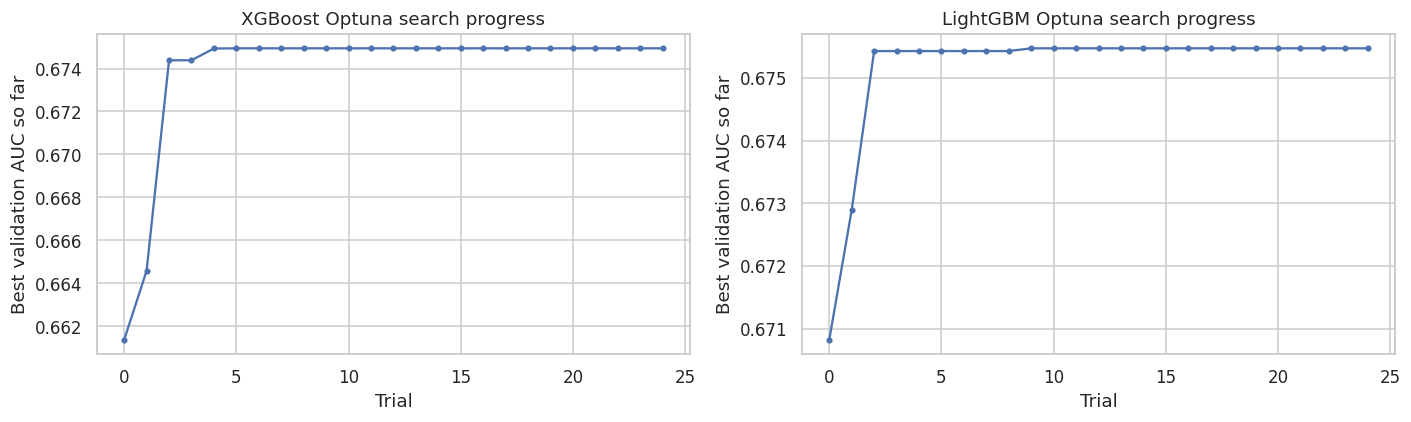

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, study, name in zip(axes, [study_xgb, study_lgbm], ["XGBoost", "LightGBM"]):
    trials = study.trials_dataframe()
    ax.plot(trials["number"], trials["value"].cummax(), marker="o", markersize=3)
    ax.set_xlabel("Trial")
    ax.set_ylabel("Best validation AUC so far")
    ax.set_title(f"{name} Optuna search progress")
save_fig(fig, "13_optuna_search_progress")


### 8.1 Refit tuned models on the full production training set, evaluate on 2023



In [31]:
scale_pos_weight_full = (y_train_prod == 0).sum() / max((y_train_prod == 1).sum(), 1)


def _build_final(name):
    if name == "xgboost_tuned":
        return Pipeline([("pre", make_preprocessor()),
                          ("model", XGBClassifier(**study_xgb.best_params, scale_pos_weight=scale_pos_weight_full,
                                                   eval_metric="auc", tree_method=XGB_TREE_METHOD,
                                                   device=XGB_DEVICE, n_jobs=-1, random_state=RANDOM_STATE))])
    if name == "lightgbm_tuned":
        return Pipeline([("pre", make_preprocessor()),
                          ("model", LGBMClassifier(**study_lgbm.best_params, class_weight="balanced",
                                                    n_jobs=-1, random_state=RANDOM_STATE, verbosity=-1))])
    if name in ("logistic_regression", "random_forest"):
        return build_model(name)
    raise ValueError(name)


# One checkpoint per final model: a resume reloads whichever fits are done and
# only re-fits the rest. CHECKPOINT_MODELS = False (setup cell) skips persisting
# the fitted objects.
final_models = {}
for name in ["logistic_regression", "random_forest", "xgboost_tuned", "lightgbm_tuned"]:
    ck = f"final_{name}"
    if ckpt_exists(ck):
        final_models[name] = ckpt_load(ck)
        continue
    t0 = time.time()
    model = _build_final(name)
    model.fit(X_train_prod, y_train_prod)
    metrics, proba, _ = evaluate_classifier(model, X_test_prod, y_test_prod)
    final_models[name] = (model, metrics, proba)
    if CHECKPOINT_MODELS:
        ckpt_save(ck, final_models[name])
    print(f"  fitted {name} in {time.time() - t0:.0f}s")
    gc.collect()

# Named handles used further down (SHAP picks the best; the save-all cell dumps each).
final_logreg = final_models["logistic_regression"][0]
final_rf = final_models["random_forest"][0]
final_xgb = final_models["xgboost_tuned"][0]
final_lgbm = final_models["lightgbm_tuned"][0]

for name, (_, m, _) in final_models.items():
    print(f"[{name:20s}] AUC={m['auc_roc']:.4f} F1={m['f1']:.4f} Precision={m['precision']:.4f} "
          f"Recall={m['recall']:.4f} Brier={m['brier']:.4f}")

pd.DataFrame({name: m for name, (_, m, _) in final_models.items()}).T.to_csv(
    OUTPUT_DIR / "final_tuned_model_metrics.csv"
)


  [checkpoint saved]    final_logistic_regression
  fitted logistic_regression in 413s
  [checkpoint saved]    final_random_forest
  fitted random_forest in 1833s
  [checkpoint saved]    final_xgboost_tuned
  fitted xgboost_tuned in 104s
  [checkpoint saved]    final_lightgbm_tuned
  fitted lightgbm_tuned in 334s
[logistic_regression ] AUC=0.6594 F1=0.3971 Precision=0.2884 Recall=0.6372 Brier=0.2367
[random_forest       ] AUC=0.6730 F1=0.4052 Precision=0.2959 Recall=0.6423 Brier=0.2317
[xgboost_tuned       ] AUC=0.6750 F1=0.4066 Precision=0.2962 Recall=0.6482 Brier=0.2321
[lightgbm_tuned      ] AUC=0.6755 F1=0.4072 Precision=0.2974 Recall=0.6455 Brier=0.2316


### 8.2 ROC curves, confusion matrices, calibration -- final tuned models on 2023 test set

[saved] 14_roc_curves.png


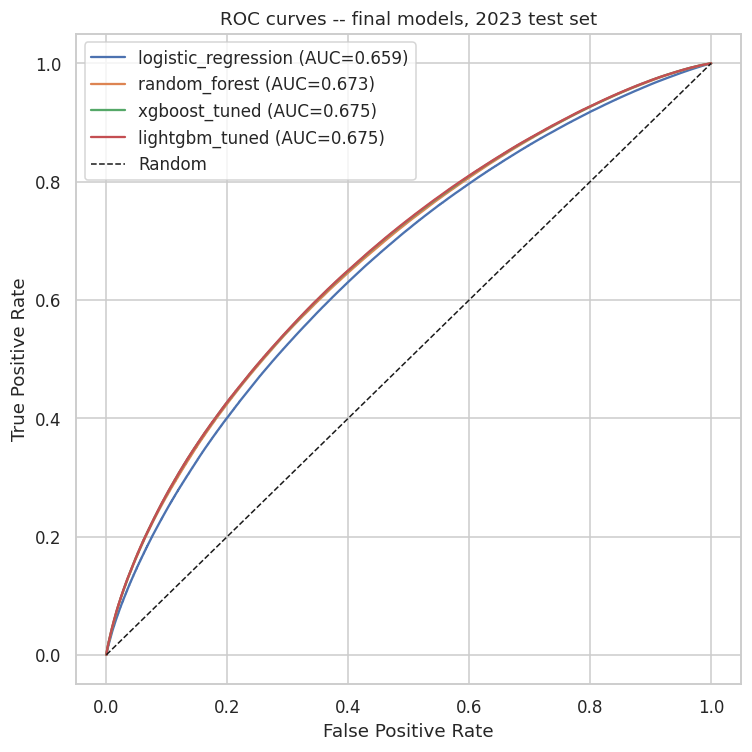

In [32]:
fig, ax = plt.subplots(figsize=(7, 7))
for name, (_, m, proba) in final_models.items():
    fpr, tpr, _ = roc_curve(y_test_prod, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={m['auc_roc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves -- final models, 2023 test set")
ax.legend()
save_fig(fig, "14_roc_curves")


[saved] 15_confusion_matrices.png


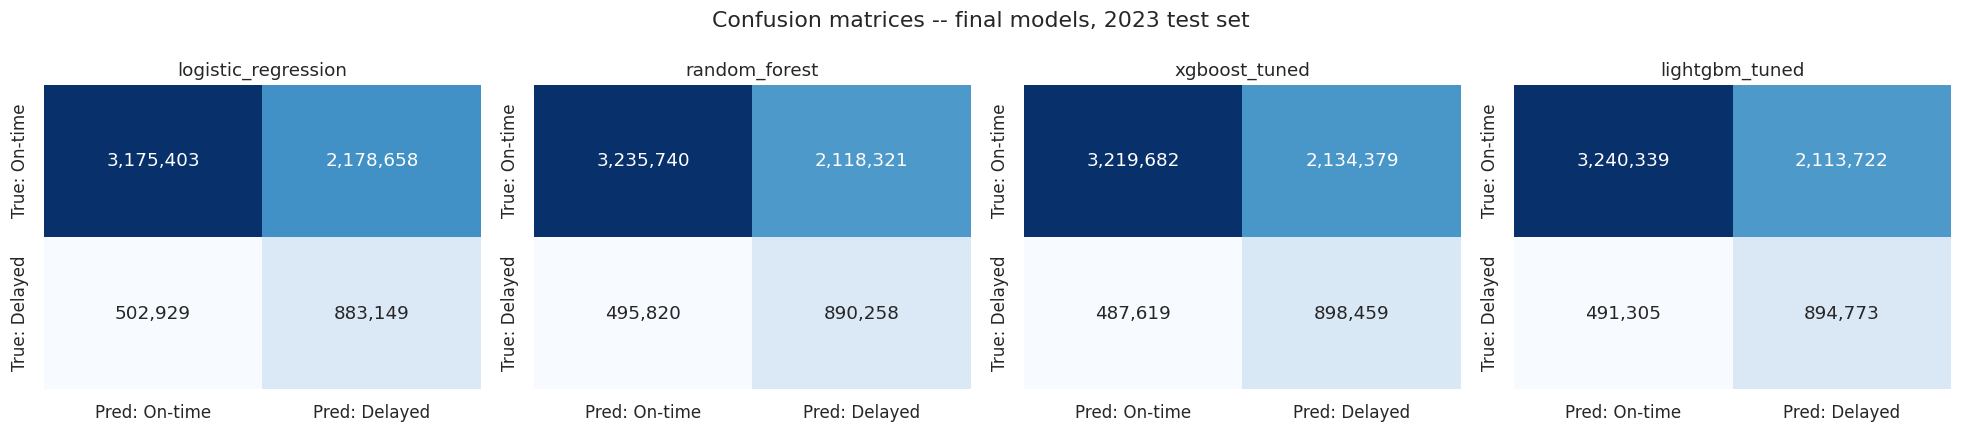

In [33]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, (_, m, proba)) in zip(axes, final_models.items()):
    pred = (proba >= 0.5).astype(int)
    cm = confusion_matrix(y_test_prod, pred, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["Pred: On-time", "Pred: Delayed"],
                yticklabels=["True: On-time", "True: Delayed"])
    ax.set_title(name)
fig.suptitle("Confusion matrices -- final models, 2023 test set")
save_fig(fig, "15_confusion_matrices")


[saved] 16_calibration_curves.png


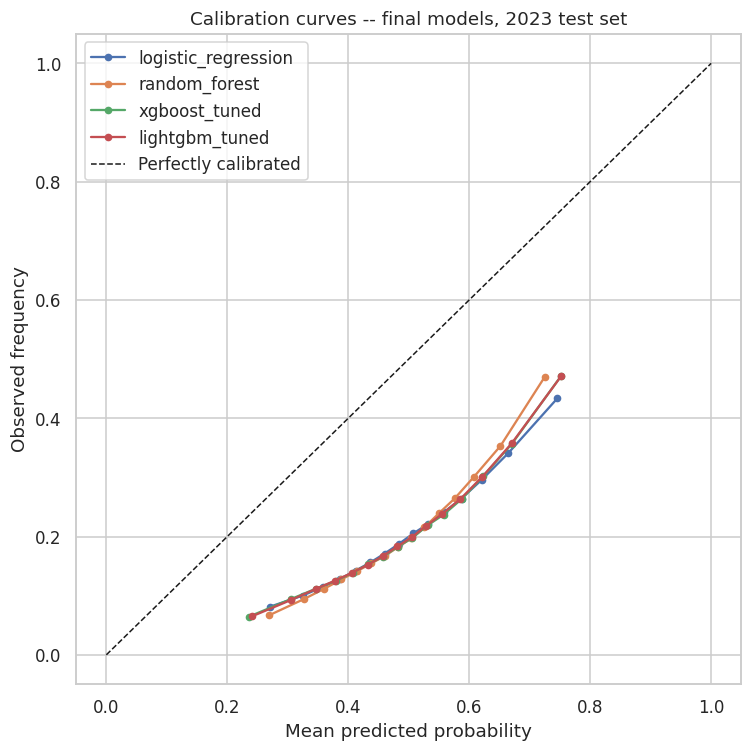

In [34]:
fig, ax = plt.subplots(figsize=(7, 7))
for name, (_, m, proba) in final_models.items():
    frac_pos, mean_pred = calibration_curve(y_test_prod, proba, n_bins=15, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", markersize=4, label=name)
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed frequency")
ax.set_title("Calibration curves -- final models, 2023 test set")
ax.legend()
save_fig(fig, "16_calibration_curves")


## 9. Model Interpretability (SHAP)




In [35]:
if ckpt_exists("shap"):
    _s = ckpt_load("shap")
    best_model_name = _s["best_model_name"]
    X_shap, shap_values, feature_names = _s["X_shap"], _s["shap_values"], _s["feature_names"]
    best_model = final_models[best_model_name][0]
    print(f"Best model by test AUC: {best_model_name}  (SHAP restored for {len(X_shap):,} rows)")
else:
    best_model_name = max(final_models, key=lambda k: final_models[k][1]["auc_roc"])
    best_model, _, _ = final_models[best_model_name]
    print(f"Best model by test AUC: {best_model_name}")

    X_test_transformed = best_model.named_steps["pre"].transform(X_test_prod)
    feature_names = best_model.named_steps["pre"].get_feature_names_out()
    X_test_transformed = pd.DataFrame(
        X_test_transformed.toarray() if hasattr(X_test_transformed, "toarray") else X_test_transformed,
        columns=feature_names,
    )

    shap_sample_idx = np.random.RandomState(RANDOM_STATE).choice(
        len(X_test_transformed), size=min(SHAP_SAMPLE_SIZE, len(X_test_transformed)), replace=False
    )
    X_shap = X_test_transformed.iloc[shap_sample_idx].copy()
    del X_test_transformed
    gc.collect()

    model_obj = best_model.named_steps["model"]
    if best_model_name == "logistic_regression":
        explainer = shap.LinearExplainer(model_obj, X_shap)
    else:
        explainer = shap.TreeExplainer(model_obj)  # random_forest, xgboost_tuned, lightgbm_tuned
    shap_values = explainer.shap_values(X_shap)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # positive class for binary classifiers that return a list

    ckpt_save("shap", {"best_model_name": best_model_name, "X_shap": X_shap,
                        "shap_values": shap_values, "feature_names": feature_names})
    print(f"SHAP values computed on {len(X_shap):,} sampled test rows")


Best model by test AUC: lightgbm_tuned
  [checkpoint saved]    shap
SHAP values computed on 8,000 sampled test rows


[saved] 17_shap_summary_beeswarm.png


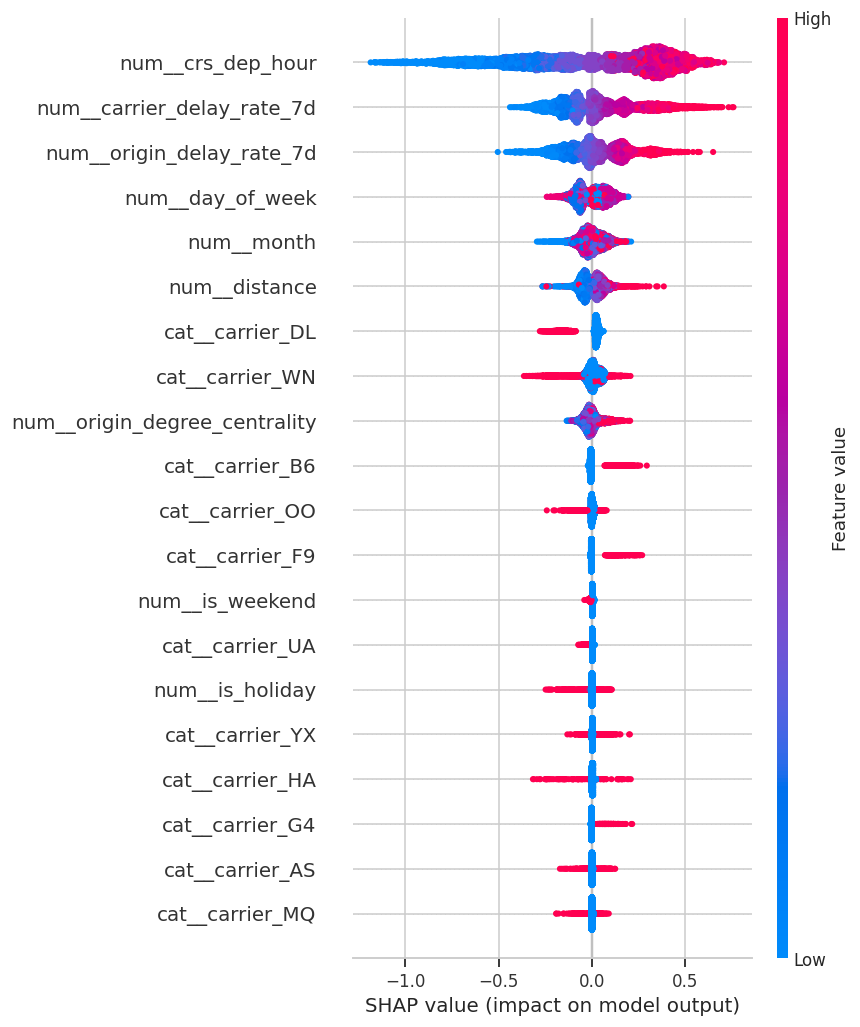

In [36]:
# shap.summary_plot creates its own figure internally -- grab it via plt.gcf()
# afterwards rather than pre-creating one (a pre-created empty figure would be
# left unused and unsaved).
shap.summary_plot(shap_values, X_shap, show=False)
save_fig(plt.gcf(), "17_shap_summary_beeswarm")


[saved] 18_shap_mean_abs_importance.png


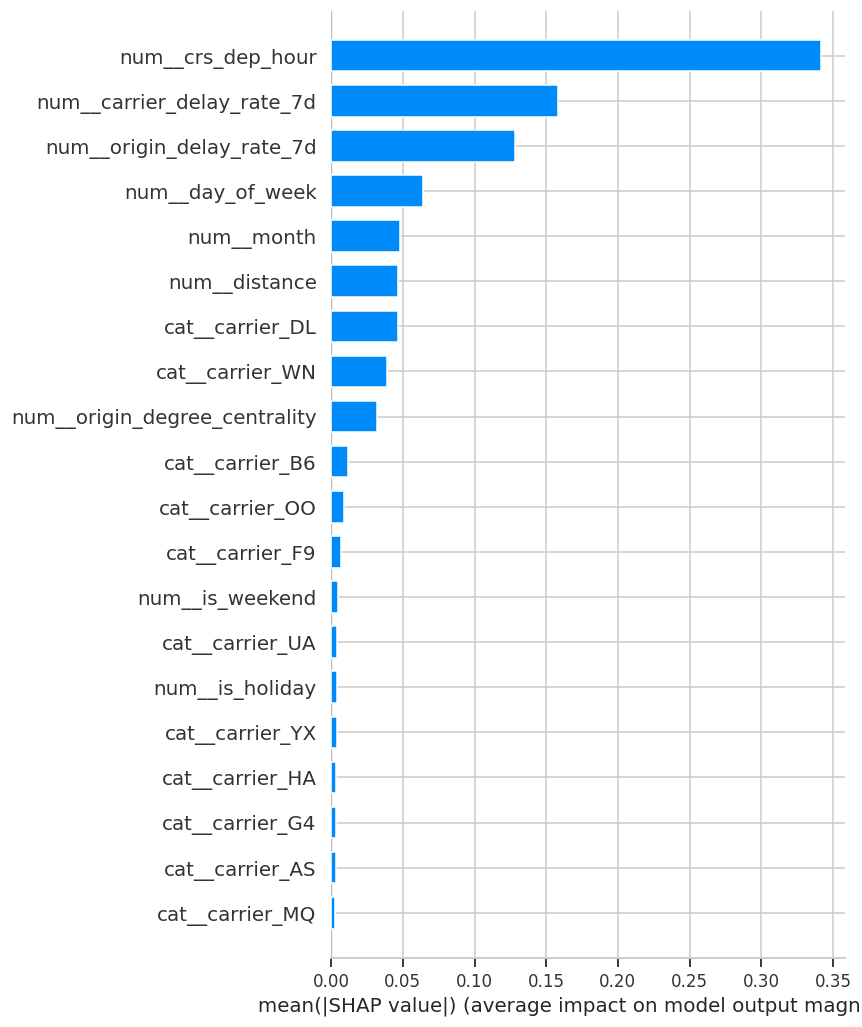

In [37]:
shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False)
save_fig(plt.gcf(), "18_shap_mean_abs_importance")


## 10. Delay-Duration Regression Sub-Model



In [38]:
train_delayed = df[(df["year"].isin(WALK_FORWARD_FOLDS[2]["train_years"])) & (df["arr_del15"] == 1)]
test_delayed = df[(df["year"] == WALK_FORWARD_FOLDS[2]["test_year"]) & (df["arr_del15"] == 1)]
print(f"Delayed flights -- train: {len(train_delayed):,}, test: {len(test_delayed):,}")

reg_val_cutoff = train_delayed["flight_date"].quantile(0.85)
reg_tr_inner = train_delayed[train_delayed["flight_date"] < reg_val_cutoff]
reg_val_inner = train_delayed[train_delayed["flight_date"] >= reg_val_cutoff]


def objective_reg(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 150, 500),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
    }
    model = Pipeline([("pre", make_preprocessor()),
                       ("model", LGBMRegressor(**params, n_jobs=-1, random_state=RANDOM_STATE, verbosity=-1))])
    return _fit_and_score(model, reg_tr_inner[ALL_FEATURES], reg_tr_inner["arr_delay_minutes"],
                           reg_val_inner[ALL_FEATURES], reg_val_inner["arr_delay_minutes"],
                           mean_absolute_error, proba=False)


t0 = time.time()
study_reg = _run_study("lgbm_duration_regressor_hpo", objective_reg, OPTUNA_TRIALS_REGRESSOR, "minimize")
print(f"Duration regressor HPO: best val MAE={study_reg.best_value:.2f} min in {time.time() - t0:.0f}s")
print("Best params:", study_reg.best_params)


Delayed flights -- train: 4,117,160, test: 1,386,078
  lgbm_duration_regressor_hpo: 0/20 trials stored -- running 20 more


  0%|          | 0/20 [00:00<?, ?it/s]

Duration regressor HPO: best val MAE=47.32 min in 491s
Best params: {'n_estimators': 316, 'num_leaves': 102, 'learning_rate': 0.06900761731140262, 'feature_fraction': 0.6630771634946331, 'bagging_fraction': 0.7476954781156898}


In [39]:
if ckpt_exists("final_regressor"):
    _r = ckpt_load("final_regressor")
    final_regressor, reg_metrics = _r["model"], _r["metrics"]
    reg_pred = final_regressor.predict(test_delayed[ALL_FEATURES])
else:
    final_regressor = Pipeline([("pre", make_preprocessor()),
                                 ("model", LGBMRegressor(**study_reg.best_params, n_jobs=-1,
                                                          random_state=RANDOM_STATE, verbosity=-1))])
    final_regressor.fit(train_delayed[ALL_FEATURES], train_delayed["arr_delay_minutes"])
    reg_pred = final_regressor.predict(test_delayed[ALL_FEATURES])

    reg_metrics = {
        "mae": mean_absolute_error(test_delayed["arr_delay_minutes"], reg_pred),
        "rmse": float(np.sqrt(mean_squared_error(test_delayed["arr_delay_minutes"], reg_pred))),
        "r2": r2_score(test_delayed["arr_delay_minutes"], reg_pred),
    }
    if CHECKPOINT_MODELS:
        ckpt_save("final_regressor", {"model": final_regressor, "metrics": reg_metrics})

print(f"Duration regressor -- test set (2023, delayed flights only): {reg_metrics}")
pd.Series(reg_metrics).to_csv(OUTPUT_DIR / "duration_regressor_metrics.csv")


  [checkpoint saved]    final_regressor
Duration regressor -- test set (2023, delayed flights only): {'mae': 49.251376560193656, 'rmse': 100.92939632102852, 'r2': 0.022981098188459725}


[saved] 19_duration_regressor_predicted_vs_actual.png


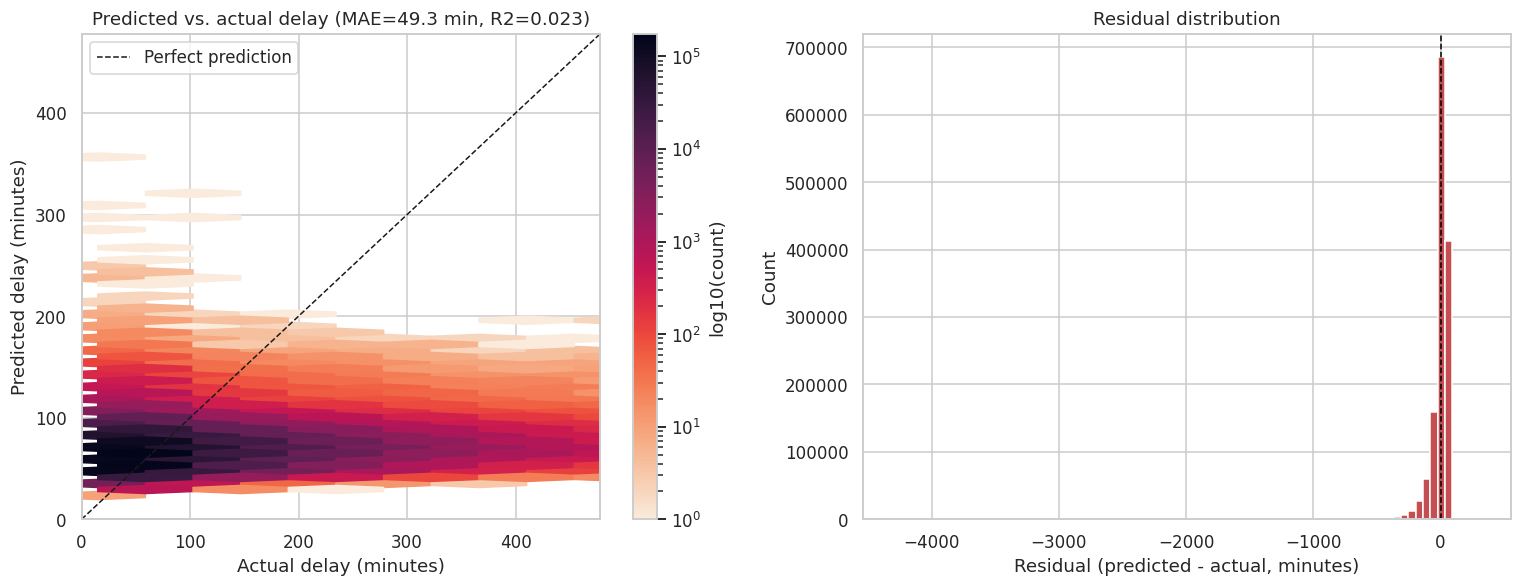

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

hb = axes[0].hexbin(test_delayed["arr_delay_minutes"], reg_pred, gridsize=50, cmap="rocket_r",
                     mincnt=1, bins="log")
lims = [0, max(test_delayed["arr_delay_minutes"].quantile(0.99), reg_pred.max())]
axes[0].plot(lims, lims, "k--", linewidth=1, label="Perfect prediction")
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel("Actual delay (minutes)")
axes[0].set_ylabel("Predicted delay (minutes)")
axes[0].set_title(f"Predicted vs. actual delay (MAE={reg_metrics['mae']:.1f} min, R2={reg_metrics['r2']:.3f})")
axes[0].legend()
fig.colorbar(hb, ax=axes[0], label="log10(count)")

residuals = reg_pred - test_delayed["arr_delay_minutes"].values
axes[1].hist(residuals, bins=80, color="#C44E52")
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("Residual (predicted - actual, minutes)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution")

save_fig(fig, "19_duration_regressor_predicted_vs_actual")


## 11. Fairness & Bias Evaluation



In [41]:
def geo_quadrant(lat, lon):
    """Vectorised NS/EW quadrant from origin coordinates (no external region data --
    ~39N and ~95W are simple splits of the continental US, not an official boundary)."""
    ns = np.where(lat >= 39, "N", "S")
    ew = np.where(lon <= -95, "W", "E")
    return pd.Series(ns, index=lat.index) + pd.Series(ew, index=lat.index)


test_prod_full = df[df["year"] == WALK_FORWARD_FOLDS[2]["test_year"]].copy()
test_prod_full["geo_quadrant"] = geo_quadrant(test_prod_full["origin_lat"], test_prod_full["origin_lon"])
# Re-predict directly on test_prod_full rather than reusing an earlier proba array,
# so there is no dependence on row-order alignment between DataFrame slices.
test_prod_full["pred_proba"] = best_model.predict_proba(test_prod_full[ALL_FEATURES])[:, 1]
test_prod_full["pred"] = (test_prod_full["pred_proba"] >= 0.5).astype(int)


def fairness_table(group_col):
    rows = []
    for g, gdf in test_prod_full.groupby(group_col, observed=True):
        if len(gdf) < 200:
            continue
        tn, fp, fn, tp = confusion_matrix(gdf["arr_del15"], gdf["pred"], labels=[0, 1]).ravel()
        tpr = tp / (tp + fn) if (tp + fn) else np.nan
        fpr = fp / (fp + tn) if (fp + tn) else np.nan
        rows.append({
            "group": g, "n": len(gdf),
            "auc": roc_auc_score(gdf["arr_del15"], gdf["pred_proba"]) if gdf["arr_del15"].nunique() > 1 else np.nan,
            "f1": f1_score(gdf["arr_del15"], gdf["pred"]),
            "tpr": tpr, "fpr": fpr,
            "positive_pred_rate": gdf["pred"].mean(),
        })
    t = pd.DataFrame(rows).sort_values("n", ascending=False)
    eq_odds_gap = max(t["tpr"].max() - t["tpr"].min(), t["fpr"].max() - t["fpr"].min())
    dp_gap = t["positive_pred_rate"].max() - t["positive_pred_rate"].min()
    return t, eq_odds_gap, dp_gap


if ckpt_exists("fairness"):
    fairness_results = ckpt_load("fairness")
else:
    fairness_results = {}
    for group_col, label in [("carrier", "Carrier"), ("origin_hub_tier", "Origin hub tier"), ("geo_quadrant", "Geographic quadrant")]:
        table, eo_gap, dp_gap = fairness_table(group_col)
        fairness_results[label] = {"table": table, "equalised_odds_gap": eo_gap,
                                    "demographic_parity_gap": dp_gap, "group_col": group_col}
    ckpt_save("fairness", fairness_results)

for label, res in fairness_results.items():
    print(f"\n--- {label} ---  equalised-odds gap={res['equalised_odds_gap']:.3f}  "
          f"demographic-parity gap={res['demographic_parity_gap']:.3f}")
    print(res["table"].to_string(index=False))
    res["table"].to_csv(OUTPUT_DIR / f"fairness_{res['group_col']}.csv", index=False)


  [checkpoint saved]    fairness

--- Carrier ---  equalised-odds gap=0.577  demographic-parity gap=0.585
group       n      auc       f1      tpr      fpr  positive_pred_rate
   WN 1421238 0.709809 0.448647 0.725909 0.421201            0.487656
   DL  972931 0.655782 0.326780 0.395217 0.200353            0.232250
   AA  928058 0.651828 0.419731 0.704765 0.495069            0.543388
   UA  720032 0.661732 0.397137 0.656551 0.428269            0.475314
   OO  661596 0.600809 0.288537 0.408052 0.275501            0.297035
   YX  286490 0.622306 0.271412 0.526993 0.354179            0.376760
   B6  267915 0.675938 0.517140 0.882573 0.693684            0.752589
   NK  258838 0.665636 0.494232 0.795474 0.585442            0.646648
   AS  242643 0.611261 0.350398 0.572364 0.414077            0.445160
   MQ  224695 0.614022 0.332880 0.530704 0.367745            0.397330
   9E  196905 0.612689 0.271919 0.410831 0.260428            0.281359
   OH  191072 0.619620 0.318649 0.488693 0.314583     

[saved] 20_fairness_group_auc.png


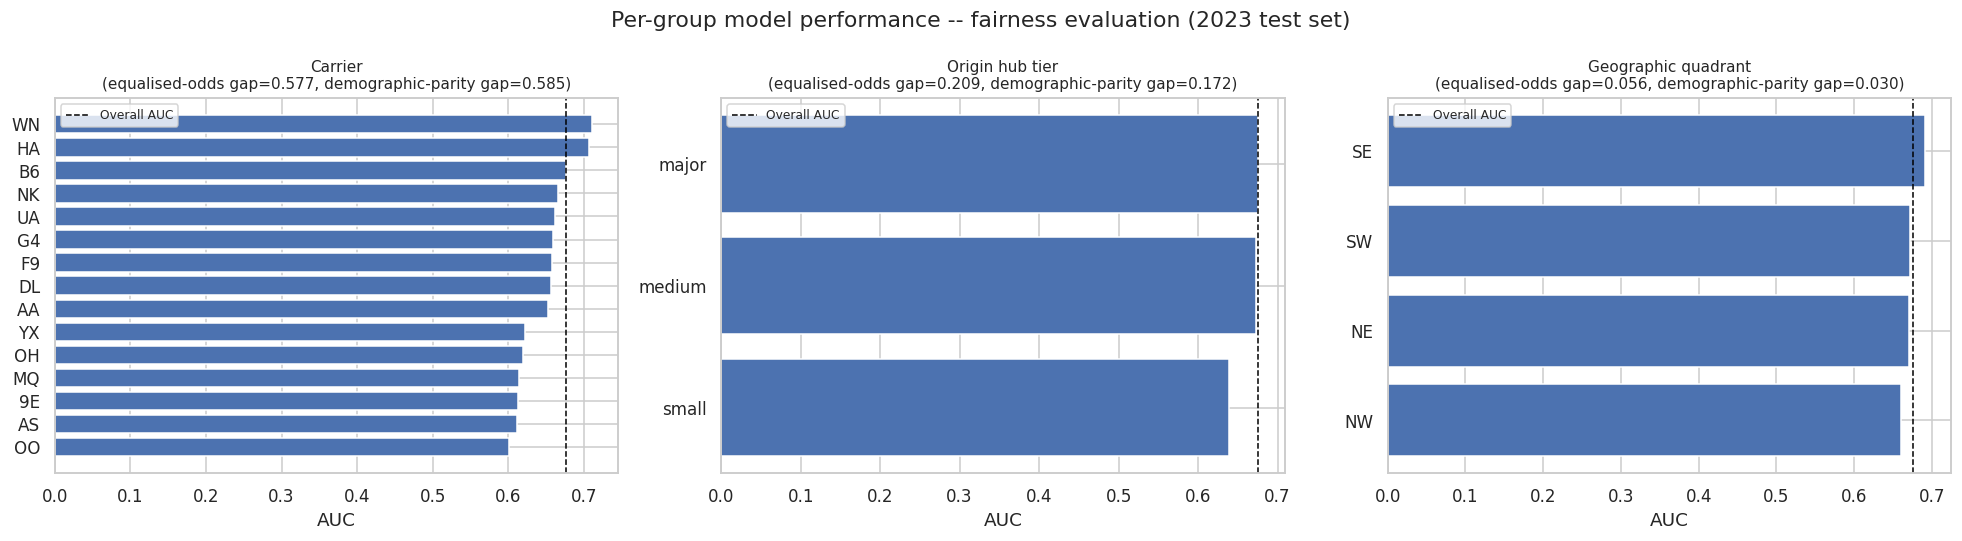

In [42]:
overall_auc = roc_auc_score(test_prod_full["arr_del15"], test_prod_full["pred_proba"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (label, res) in zip(axes, fairness_results.items()):
    t = res["table"].sort_values("auc")
    ax.barh(t["group"].astype(str), t["auc"], color="#4C72B0")
    ax.axvline(overall_auc, color="black", linestyle="--", linewidth=1, label="Overall AUC")
    ax.set_xlabel("AUC")
    ax.set_title(f"{label}\n(equalised-odds gap={res['equalised_odds_gap']:.3f}, "
                 f"demographic-parity gap={res['demographic_parity_gap']:.3f})", fontsize=10)
    ax.legend(fontsize=8)
fig.suptitle("Per-group model performance -- fairness evaluation (2023 test set)")
save_fig(fig, "20_fairness_group_auc")


## 12. COVID-19 Period Distribution-Shift Check


In [43]:
if ckpt_exists("covid_check"):
    covid_check_df = ckpt_load("covid_check")
else:
    covid_check_rows = []
    for year in [2020, 2021, WALK_FORWARD_FOLDS[2]["test_year"]]:
        year_df = df[df["year"] == year]
        proba = final_models[best_model_name][0].predict_proba(year_df[ALL_FEATURES])[:, 1]
        pred = (proba >= 0.5).astype(int)
        covid_check_rows.append({
            "year": year,
            "label": "In-distribution (2023)" if year == WALK_FORWARD_FOLDS[2]["test_year"] else "COVID period (excluded from training)",
            "n": len(year_df),
            "actual_delay_rate": year_df["arr_del15"].mean(),
            "auc": roc_auc_score(year_df["arr_del15"], proba),
            "f1": f1_score(year_df["arr_del15"], pred),
        })
    covid_check_df = pd.DataFrame(covid_check_rows)
    ckpt_save("covid_check", covid_check_df)

covid_check_df.to_csv(OUTPUT_DIR / "covid_distribution_shift_check.csv", index=False)
covid_check_df


  [checkpoint saved]    covid_check


,year,label,n,actual_delay_rate,auc,f1
0,2020,COVID period (excluded from training),4396951,0.098168,0.630846,0.198456
1,2021,COVID period (excluded from training),5874238,0.171867,0.690233,0.381987
2,2023,In-distribution (2023),6740139,0.205645,0.675471,0.407217


[saved] 21_covid_distribution_shift.png


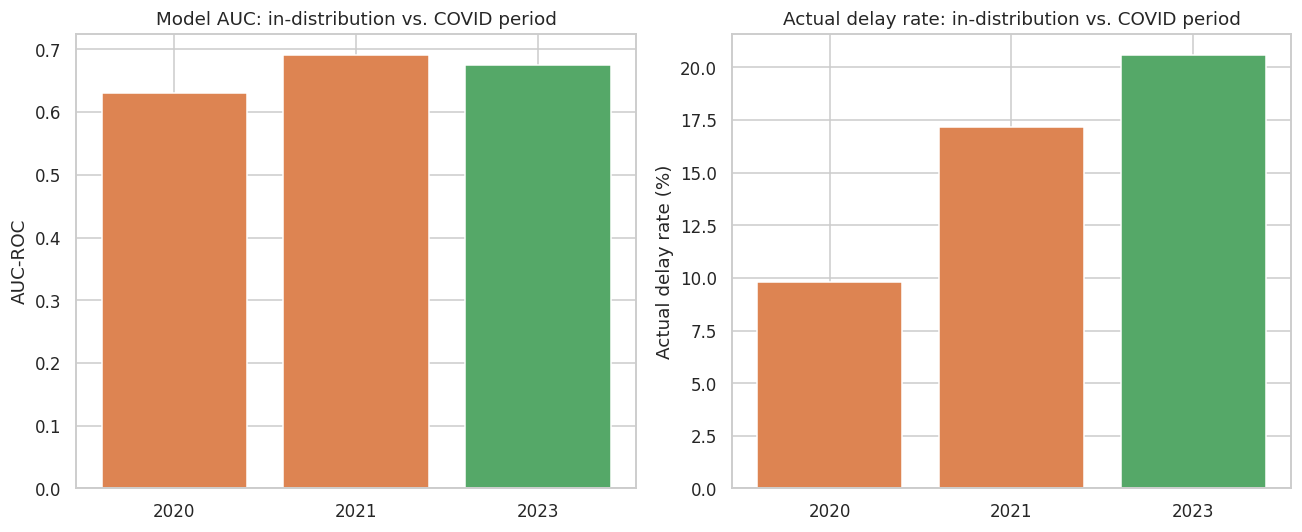

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ["#DD8452" if "COVID" in l else "#55A868" for l in covid_check_df["label"]]
axes[0].bar(covid_check_df["year"].astype(str), covid_check_df["auc"], color=colors)
axes[0].set_ylabel("AUC-ROC")
axes[0].set_title("Model AUC: in-distribution vs. COVID period")
axes[1].bar(covid_check_df["year"].astype(str), covid_check_df["actual_delay_rate"]*100, color=colors)
axes[1].set_ylabel("Actual delay rate (%)")
axes[1].set_title("Actual delay rate: in-distribution vs. COVID period")
save_fig(fig, "21_covid_distribution_shift")


## 13. Model Comparison Summary

In [45]:
summary_rows = []
for name, (_, m, _) in final_models.items():
    summary_rows.append({"model": name, **m})
summary_rows.append({"model": "duration_regressor (LightGBM, MAE/RMSE shown as auc_roc/f1 cols)",
                      "auc_roc": reg_metrics["mae"], "f1": reg_metrics["rmse"],
                      "precision": reg_metrics["r2"], "recall": np.nan, "brier": np.nan})
final_summary_df = pd.DataFrame(summary_rows)
final_summary_df.to_csv(OUTPUT_DIR / "final_model_comparison_summary.csv", index=False)
final_summary_df


,model,auc_roc,f1,precision,recall,brier
0,logistic_regression,0.659378,0.397110,0.288440,0.637157,0.236690
1,random_forest,0.672976,0.405155,0.295906,0.642286,0.231686
2,xgboost_tuned,0.674978,0.406642,0.296244,0.648202,0.232134
3,lightgbm_tuned,0.675471,0.407217,0.297415,0.645543,0.231571
4,"duration_regressor (LightGBM, MAE/RMSE shown a...",49.251377,100.929396,0.022981,NaN,NaN


## 14. Save All Figures & Models, Download as ZIP


In [46]:
joblib.dump(final_logreg, MODELS_DIR / "logistic_regression_final.pkl")
joblib.dump(final_rf, MODELS_DIR / "random_forest_final.pkl")
joblib.dump(final_xgb, MODELS_DIR / "xgboost_tuned_final.pkl")
joblib.dump(final_lgbm, MODELS_DIR / "lightgbm_tuned_final.pkl")
joblib.dump(final_regressor, MODELS_DIR / "lightgbm_duration_regressor_final.pkl")

best_params = {
    "xgboost": study_xgb.best_params,
    "lightgbm_classifier": study_lgbm.best_params,
    "lightgbm_regressor": study_reg.best_params,
}
with open(MODELS_DIR / "best_hyperparameters.json", "w") as f:
    json.dump(best_params, f, indent=2)

with open(OUTPUT_DIR / "run_config.json", "w") as f:
    json.dump({
        "rf_n_estimators": RF_N_ESTIMATORS,
        "xgb_lgbm_n_estimators": XGB_LGBM_N_ESTIMATORS,
        "optuna_trials_classifier": OPTUNA_TRIALS_CLASSIFIER,
        "optuna_trials_regressor": OPTUNA_TRIALS_REGRESSOR,
        "shap_sample_size": SHAP_SAMPLE_SIZE,
        "best_model_by_auc": best_model_name,
        "n_rows_total": int(len(df)),
    }, f, indent=2)

print("Saved models:")
for p in sorted(MODELS_DIR.glob("*")):
    print(" ", p.name)
print("\nSaved figures:")
for p in sorted(FIGURES_DIR.glob("*")):
    print(" ", p.name)


Saved models:
  best_hyperparameters.json
  lightgbm_duration_regressor_final.pkl
  lightgbm_tuned_final.pkl
  logistic_regression_final.pkl
  random_forest_final.pkl
  xgboost_tuned_final.pkl

Saved figures:
  01_class_balance.png
  02_monthly_delay_trend.png
  03_hour_dow_heatmap.png
  04_delay_rate_by_carrier.png
  05_top_airports_volume_delay.png
  06_delay_duration_violin_by_carrier.png
  07_distance_vs_delay_hexbin.png
  08_correlation_heatmap.png
  09_interactive_monthly_delay_by_carrier.html
  10_interactive_us_airport_map.html
  11_interactive_sunburst_carrier_hub.html
  12_walk_forward_model_comparison.png
  13_optuna_search_progress.png
  14_roc_curves.png
  15_confusion_matrices.png
  16_calibration_curves.png
  17_shap_summary_beeswarm.png
  18_shap_mean_abs_importance.png
  19_duration_regressor_predicted_vs_actual.png
  20_fairness_group_auc.png
  21_covid_distribution_shift.png


In [47]:
zip_path = OUTPUT_DIR.parent / f"{OUTPUT_DIR.name}.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for p in OUTPUT_DIR.rglob("*"):
        if p.is_file():
            zf.write(p, p.relative_to(OUTPUT_DIR.parent))

print(f"Zipped everything to {zip_path} ({zip_path.stat().st_size/1e6:.1f} MB)")

if IN_COLAB:
    from google.colab import files
    files.download(str(zip_path))
else:
    print(f"Not running in Colab -- find your outputs at: {zip_path.resolve()}")


Zipped everything to /content/PRT661_outputs.zip (167.5 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>